Pada kompetisi ini kami ditantang untuk membuat model machine learning yang dapat mengklasifikasikan nasabah dengan probability ke dalam dua kategori:
* 1: nasabah diprediksi akan membeli deposito berjangka
* 0: nasabah diprediksi tidak akan membeli

Berikut adalah kolom dari dataset

| No | Nama Kolom                  | Deskripsi Kolom |
|----|-----------------------------|----------------|
| 1  | customer_number             | Angka unik yang diberikan kepada setiap nasabah untuk membedakan satu nasabah dengan yang lainnya |
| 2  | usia                        | Usia nasabah (dalam tahun) |
| 3  | pekerjaan                   | Jenis pekerjaan nasabah |
| 4  | status_perkawinan           | Status perkawinan nasabah (termasuk duda/janda sebagai "cerai") |
| 5  | pendidikan                  | Tingkat pendidikan terakhir yang diselesaikan oleh nasabah |
| 6  | gagal_bayar_sebelumnya      | Apakah nasabah pernah mengalami gagal bayar kredit sebelumnya |
| 7  | pinjaman_rumah              | Apakah nasabah memiliki pinjaman rumah |
| 8  | pinjaman_pribadi            | Apakah nasabah memiliki pinjaman pribadi |
| 9  | jenis_kontak                | Jenis media komunikasi yang digunakan untuk menghubungi nasabah |
| 10 | bulan_kontak_terakhir       | Bulan ketika nasabah terakhir kali dihubungi |
| 11 | hari_kontak_terakhir        | Hari dalam seminggu ketika nasabah terakhir kali dihubungi |
| 12 | durasi_kontak               | Durasi kontak terakhir dalam satuan detik (tidak digunakan dalam model prediksi nyata karena hanya diketahui setelah kontak dilakukan) |
| 13 | jumlah_kontak_kampanye_ini  | Jumlah total kontak yang dilakukan selama kampanye saat ini |
| 14 | hari_sejak_kontak_sebelumnya | Jumlah hari sejak nasabah terakhir dihubungi dari kampanye sebelumnya (999 berarti belum pernah dihubungi sebelumnya) |
| 15 | jumlah_kontak_sebelumnya    | Jumlah kontak yang dilakukan sebelum kampanye saat ini terhadap nasabah |
| 16 | hasil_kampanye_sebelumnya   | Hasil dari kampanye pemasaran sebelumnya terhadap nasabah |
| 17 | tingkat_variasi_pekerjaan   | Indikator variasi tingkat pekerjaan secara kuartalan |
| 18 | indeks_harga_konsumen       | Indeks harga konsumen pada bulan terkait |
| 19 | indeks_kepercayaan_konsumen | Indeks tingkat kepercayaan konsumen pada bulan terkait |
| 20 | suku_bunga_euribor_3bln     | Suku bunga Euribor untuk tenor 3 bulan |
| 21 | jumlah_pekerja              | Jumlah total tenaga kerja dalam indikator kuartalan |
| 22 | berlangganan_deposito       | Apakah nasabah memutuskan untuk berlangganan produk deposito berjangka (1 berarti berlangganan deposito dan 0 berarti customer tidak berlangganan deposito) |


In [4]:
# import basic library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# download dataset
!pip install gdown -q
!gdown --id 1QlOEmXTwpQpCf2F8nA1GdnbTxrXrVRtu
!gdown --id 1ypgjcxdI0IMpLA2bQGrI02HaVG9afS0X


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1QlOEmXTwpQpCf2F8nA1GdnbTxrXrVRtu
To: /kaggle/working/validation_set.csv
100%|█████████████████████████████████████████| 726k/726k [00:00<00:00, 121MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ypgjcxdI0IMpLA2bQGrI02HaVG9afS0X
To: /kaggle/working/training_dataset.csv
100%|███████████████████████████████████████| 2.94M/2.94M [00:00<00:00, 165MB/s]


In [5]:
# read dataset and define dataframe
df_train = pd.read_csv("training_dataset.csv")
df_test = pd.read_csv("validation_set.csv")
df_train = df_train.drop(columns='customer_number')
print("Dataset total = {}".format(len(df_train.columns)))
print(df_train.columns)

Dataset total = 21
Index(['usia', 'pekerjaan', 'status_perkawinan', 'pendidikan',
       'gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi',
       'jenis_kontak', 'bulan_kontak_terakhir', 'hari_kontak_terakhir',
       'jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya',
       'jumlah_kontak_sebelumnya', 'hasil_kampanye_sebelumnya',
       'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen',
       'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln',
       'jumlah_pekerja', 'pulau', 'berlangganan_deposito'],
      dtype='object')


# EDA 1

In [4]:
def eda1(dataTrain=df_train, dataTest=df_test):
    print("\nTraining Section info\n")
    display(dataTrain.info())

    print("\nTesting Section info\n")
    display(dataTest.info())

    print("\nTraining Section head\n")
    display(dataTrain.head(2))

    print("\nTesting Section head\n")
    display(dataTest.head(2))

    print("\nTraining Section describe\n")
    display(dataTrain.describe())

    print("\nTesting Section describe\n")
    display(dataTest.describe())

    print("\nTraining Section Isnull\n")
    display(dataTrain.isnull().sum().to_frame(name="Missing Values"))

    print("\nTesting Section Isnull\n")
    display(dataTest.isnull().sum().to_frame(name="Missing Values"))

eda1()


Training Section info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   usia                          22916 non-null  int64  
 1   pekerjaan                     22916 non-null  object 
 2   status_perkawinan             22916 non-null  object 
 3   pendidikan                    22916 non-null  object 
 4   gagal_bayar_sebelumnya        22916 non-null  object 
 5   pinjaman_rumah                22916 non-null  object 
 6   pinjaman_pribadi              22916 non-null  object 
 7   jenis_kontak                  22916 non-null  object 
 8   bulan_kontak_terakhir         22916 non-null  object 
 9   hari_kontak_terakhir          22916 non-null  object 
 10  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 11  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 12  jumlah_kontak_sebelumnya      22916 

None


Testing Section info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729 entries, 0 to 5728
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               5729 non-null   int64  
 1   usia                          5729 non-null   int64  
 2   pekerjaan                     5729 non-null   object 
 3   status_perkawinan             5729 non-null   object 
 4   pendidikan                    5729 non-null   object 
 5   gagal_bayar_sebelumnya        5729 non-null   object 
 6   pinjaman_rumah                5729 non-null   object 
 7   pinjaman_pribadi              5729 non-null   object 
 8   jenis_kontak                  5729 non-null   object 
 9   bulan_kontak_terakhir         5729 non-null   object 
 10  hari_kontak_terakhir          5729 non-null   object 
 11  jumlah_kontak_kampanye_ini    5729 non-null   int64  
 12  hari_sejak_kontak_sebelumnya  5729 non-

None


Training Section head



...

,customer_number,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja
count,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000
mean,548493.630826,39.852679,2.545470,964.329377,0.162157,0.096003,93.571413,-40.471356,3.638297,5167.914662
std,258992.541542,10.348971,2.618704,182.310129,0.471306,1.565580,0.576929,4.632091,1.727321,71.802171
min,100423.000000,18.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,323527.000000,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,552893.000000,38.000000,2.000000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000
75%,772131.000000,46.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,999897.000000,98.000000,43.000000,999.000000,5.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Training Section Isnull



,Missing Values
usia,0
pekerjaan,0
status_perkawinan,0
pendidikan,0
gagal_bayar_sebelumnya,0
pinjaman_rumah,0
pinjaman_pribadi,0
jenis_kontak,0
bulan_kontak_terakhir,0
hari_kontak_terakhir,0



Testing Section Isnull



,Missing Values
customer_number,0
usia,0
pekerjaan,0
status_perkawinan,0
pendidikan,0
gagal_bayar_sebelumnya,0
pinjaman_rumah,0
pinjaman_pribadi,0
jenis_kontak,0
bulan_kontak_terakhir,0


## Analisis Density antara data train dan data test

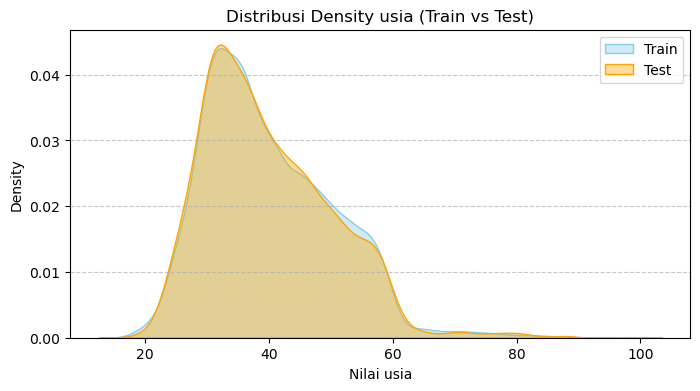

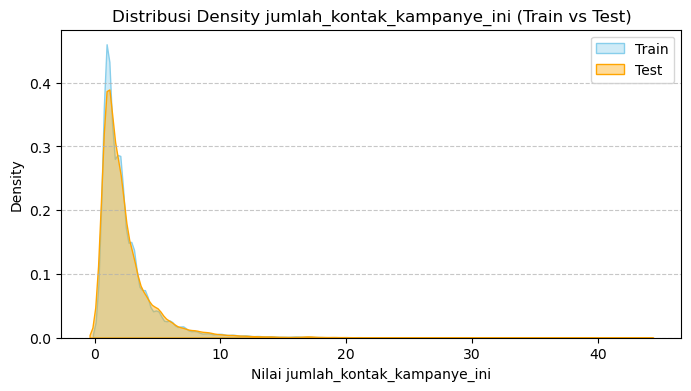

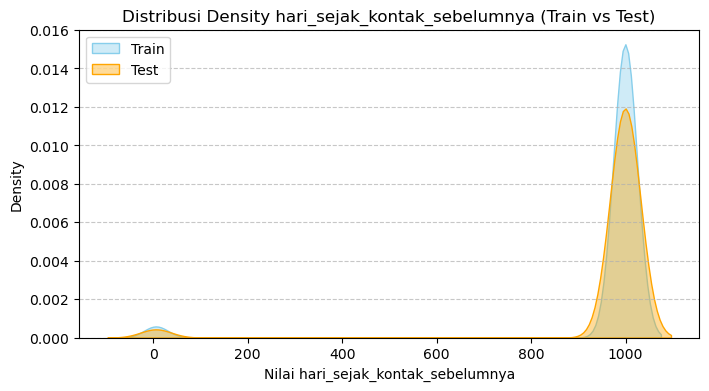

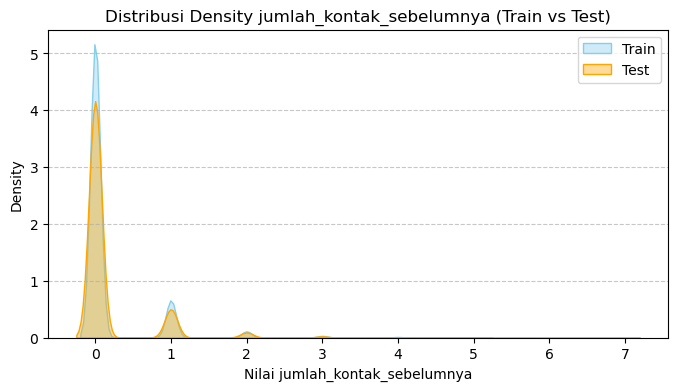

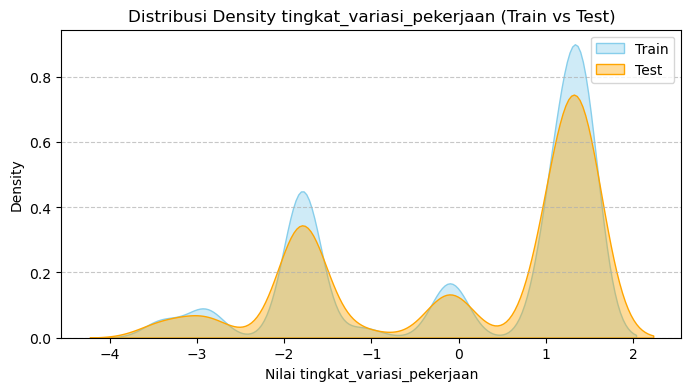

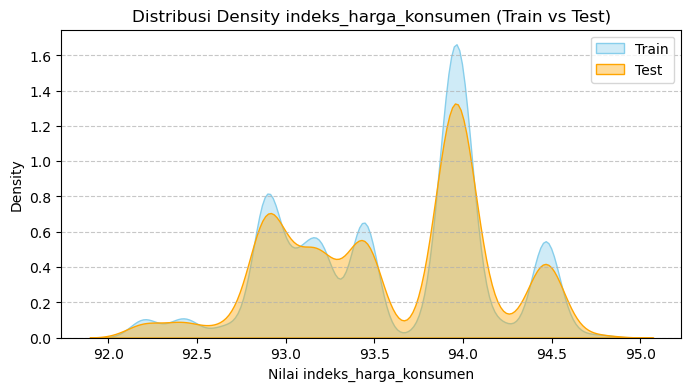

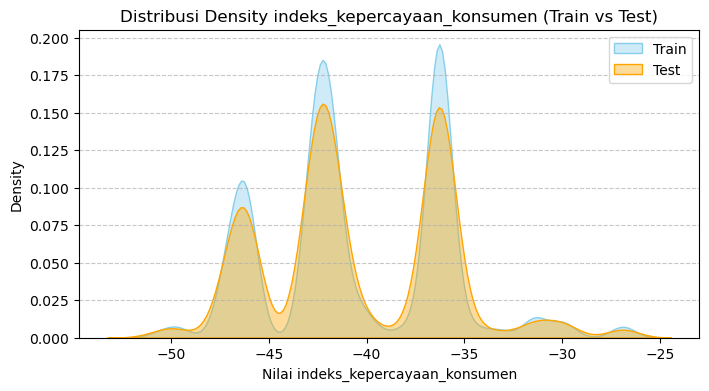

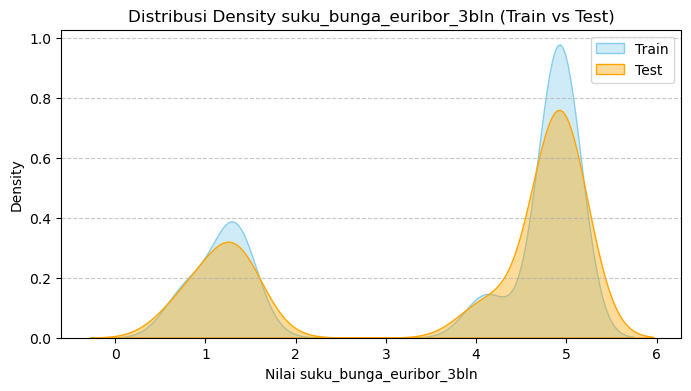

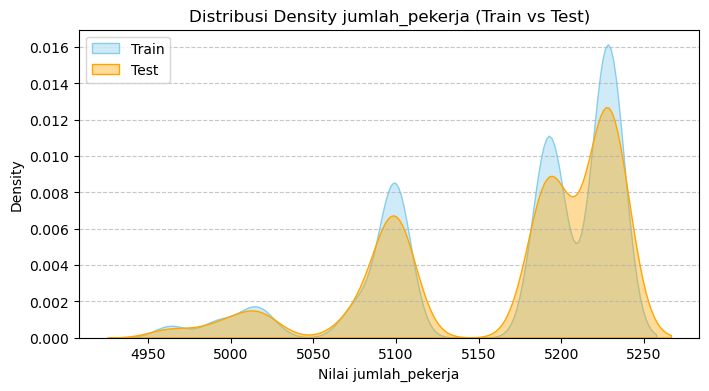

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop untuk semua kolom numerik dalam df_train dan df_test, kecuali 'berlangganan_deposito' dan 'customer_number'
excluded_columns = ['berlangganan_deposito', 'customer_number']

for col in df_train.columns:
    if df_train[col].dtype != 'object' and col not in excluded_columns:  # Hanya untuk kolom numerik yang tidak termasuk dalam excluded_columns
        plt.figure(figsize=(8, 4))
        sns.kdeplot(df_train[col], label='Train', color='skyblue', fill=True, alpha=0.4)
        sns.kdeplot(df_test[col], label='Test', color='orange', fill=True, alpha=0.4)
        plt.title(f'Distribusi Density {col} (Train vs Test)')
        plt.xlabel(f'Nilai {col}')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


## Analisis bar plot

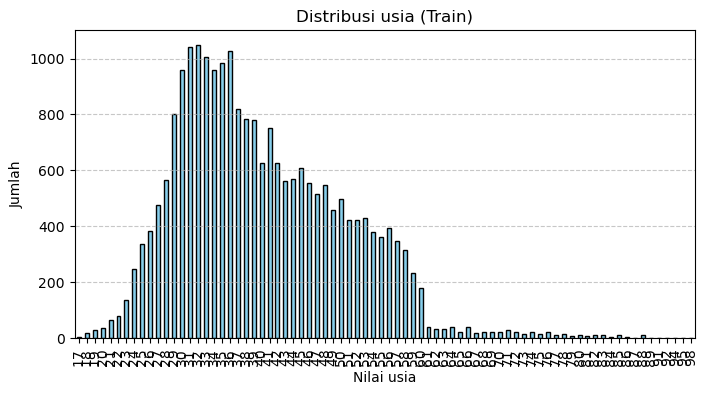

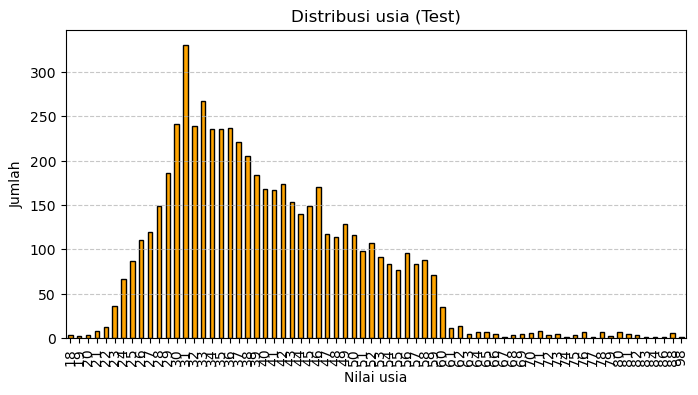

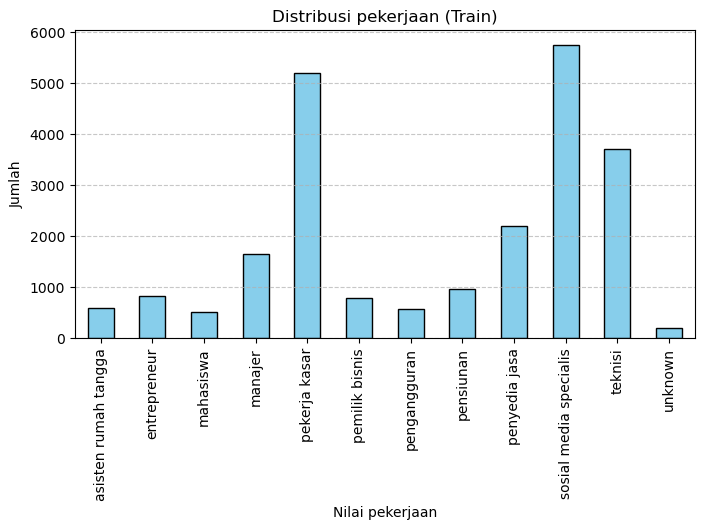

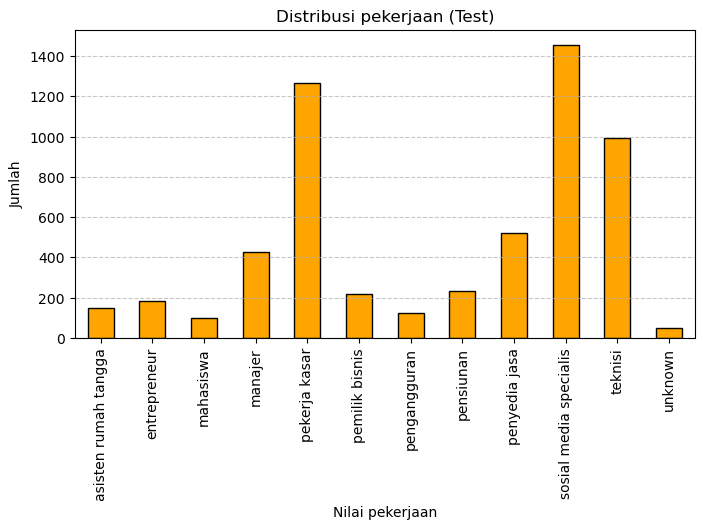

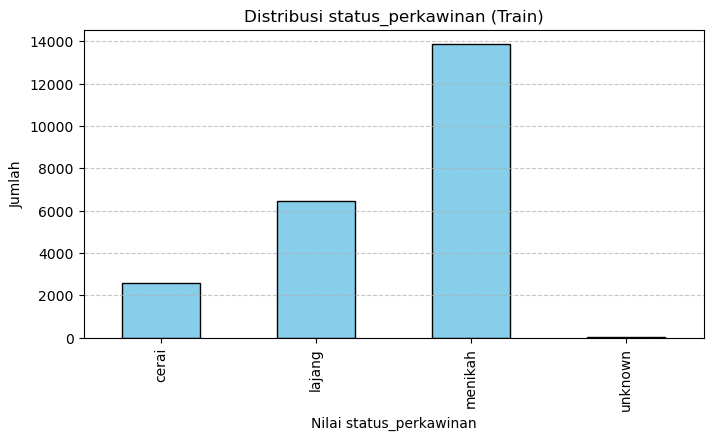

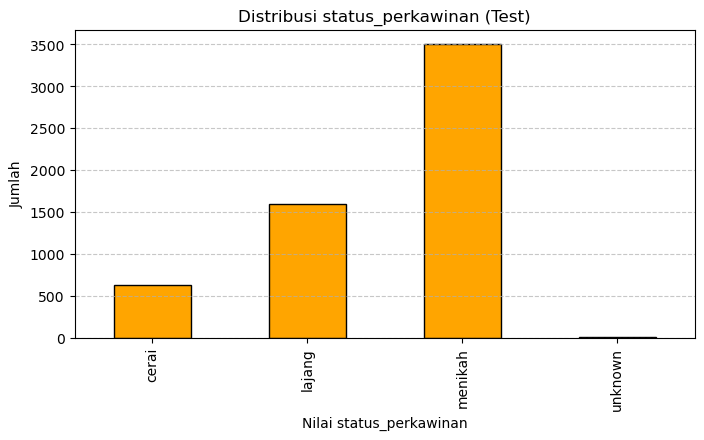

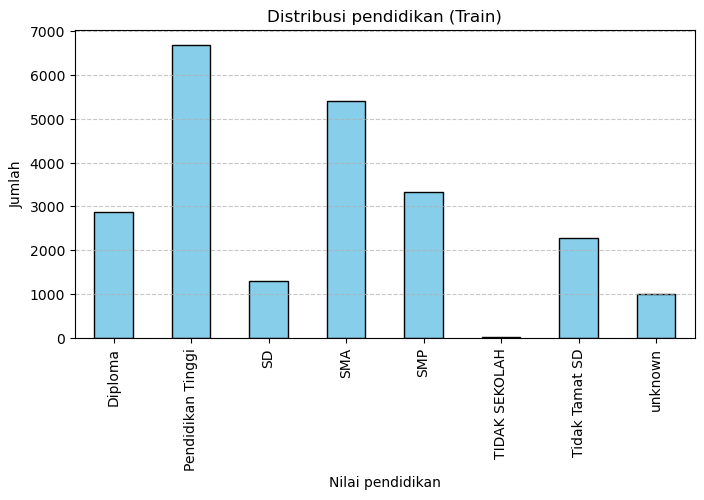

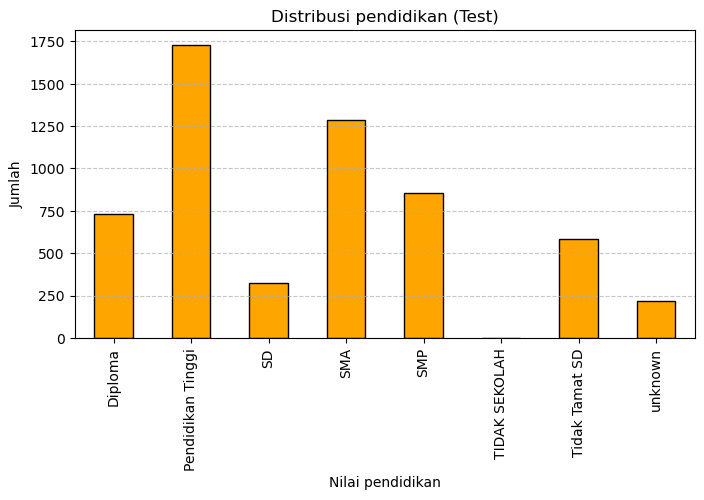

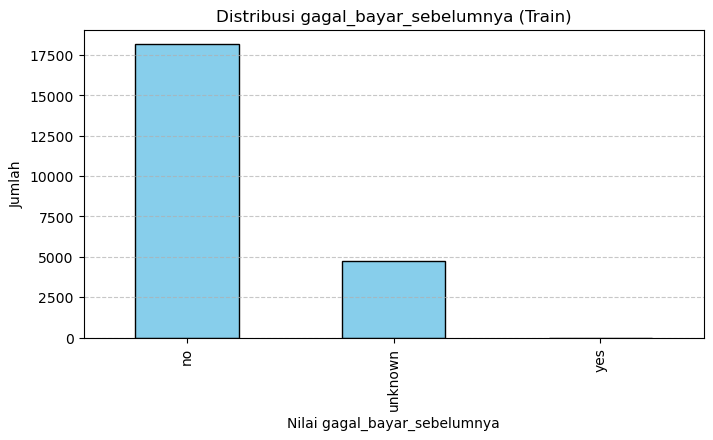

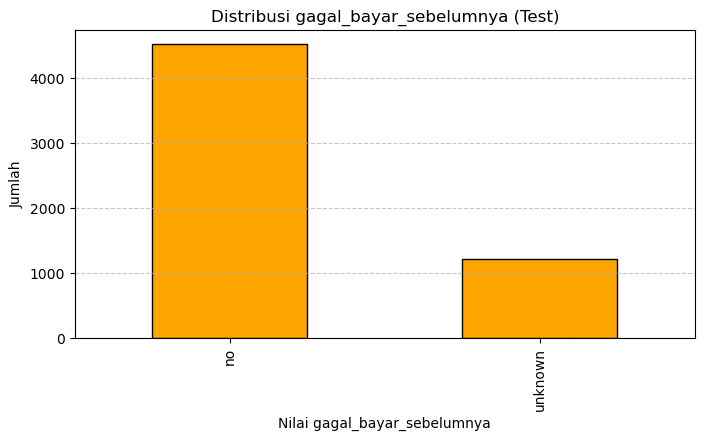

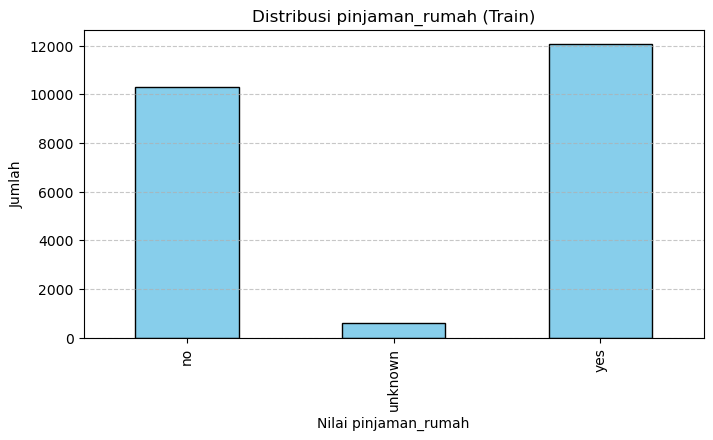

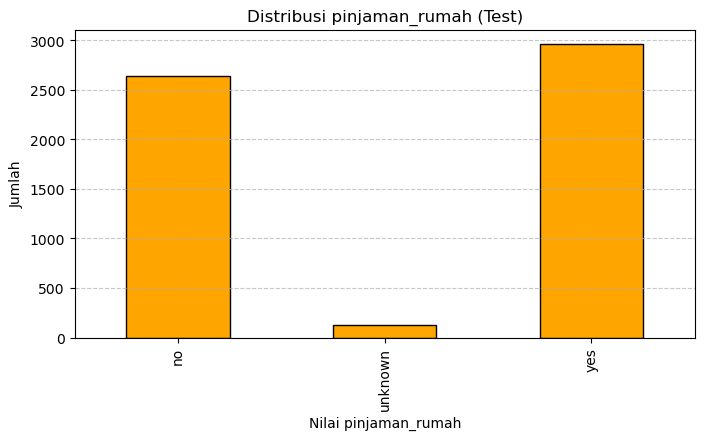

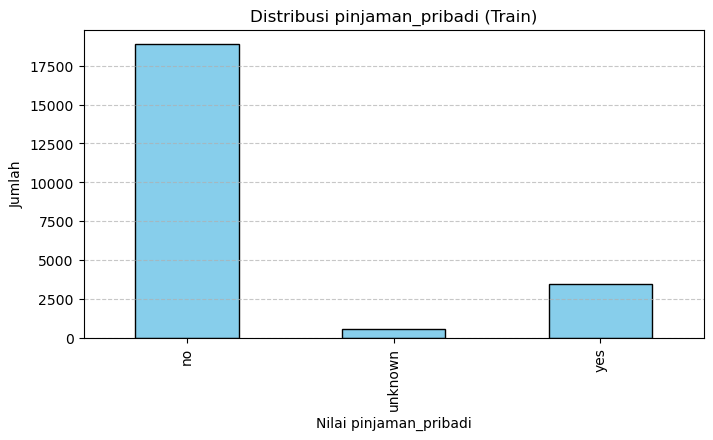

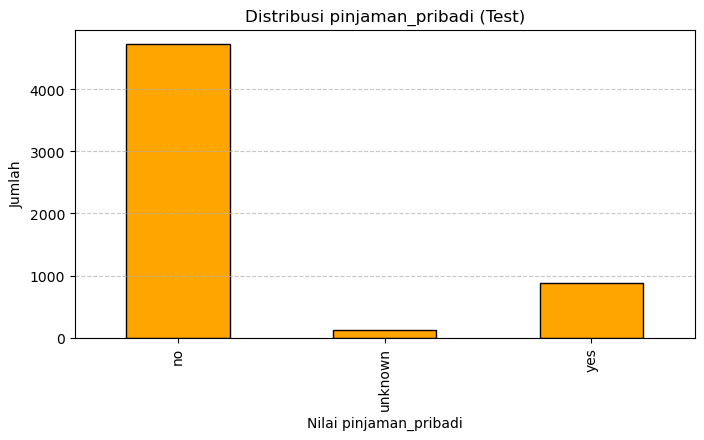

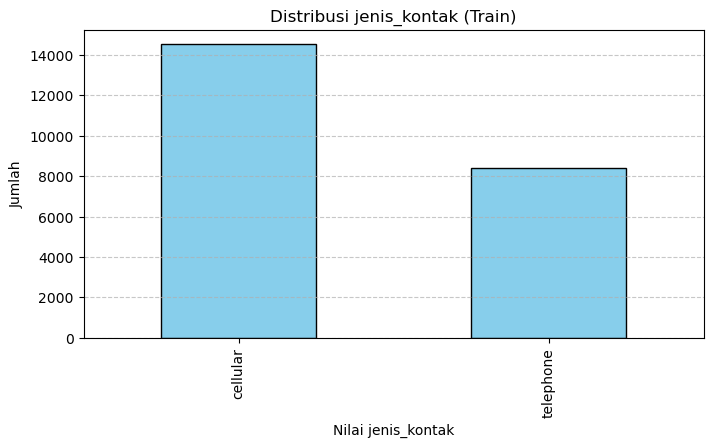

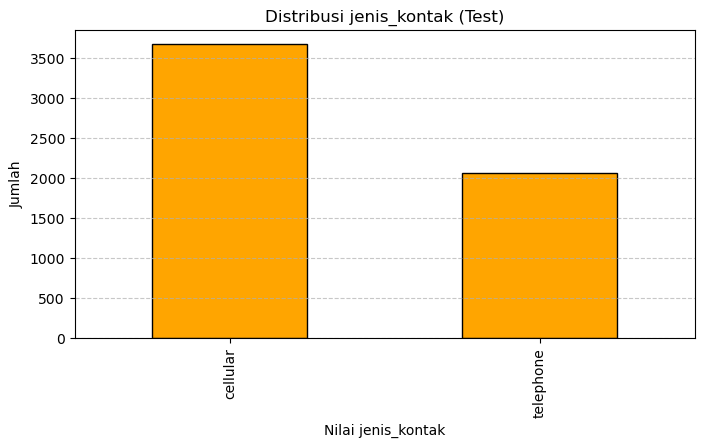

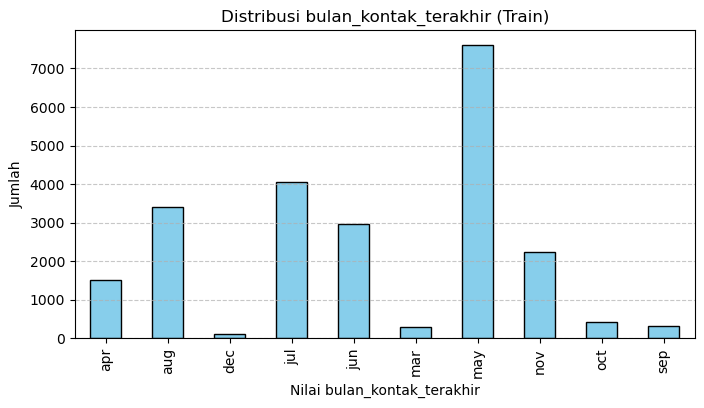

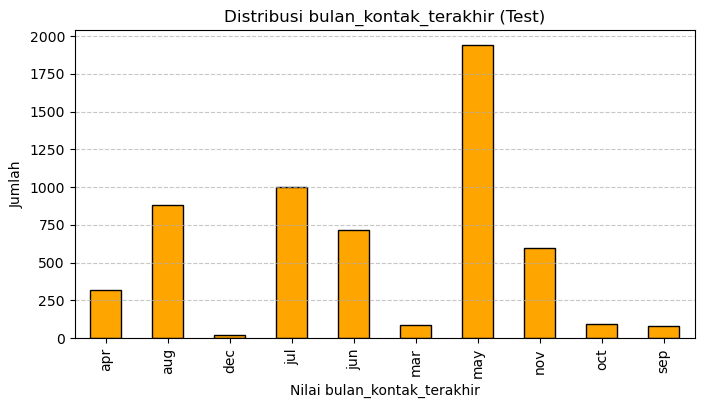

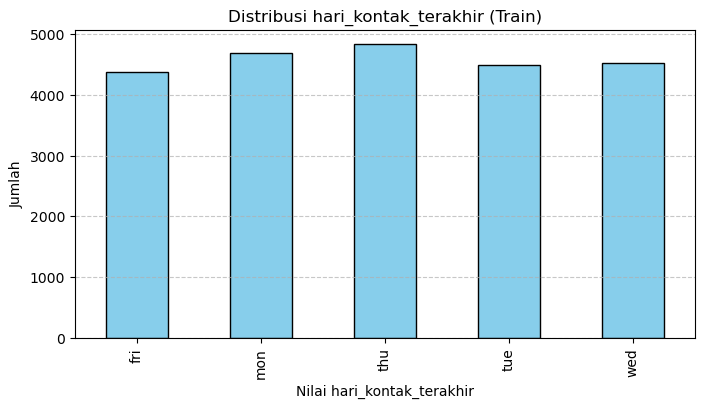

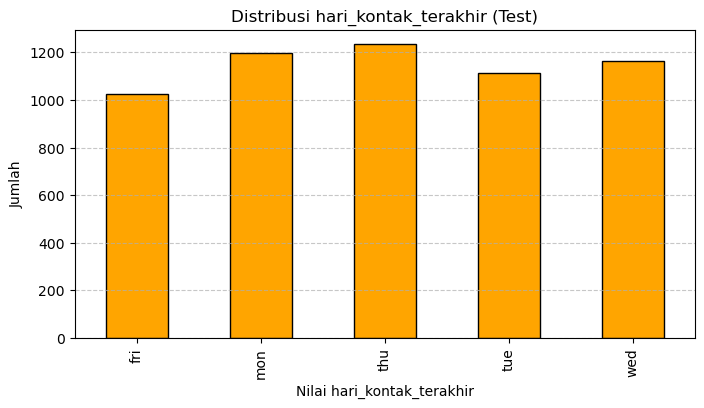

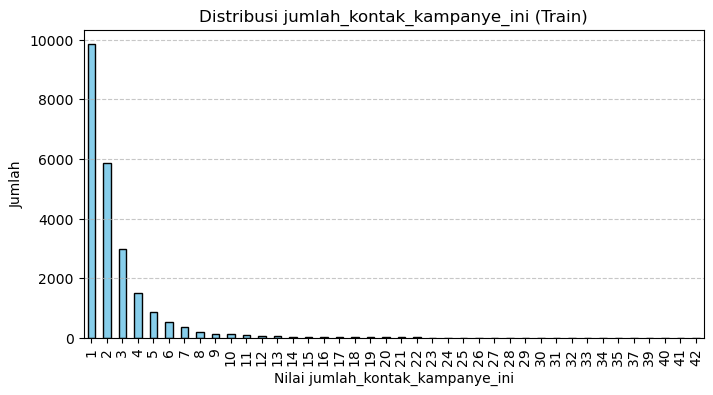

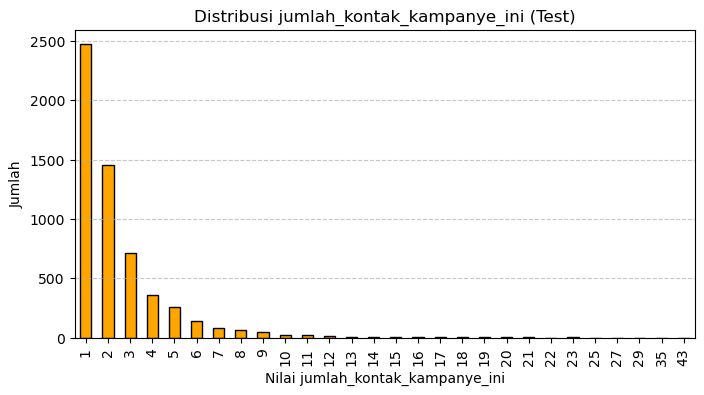

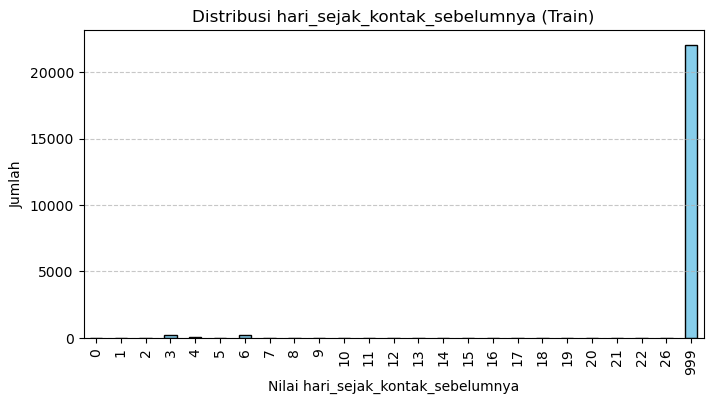

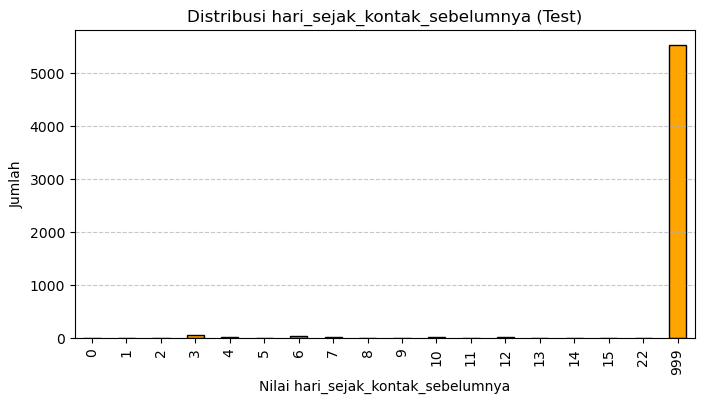

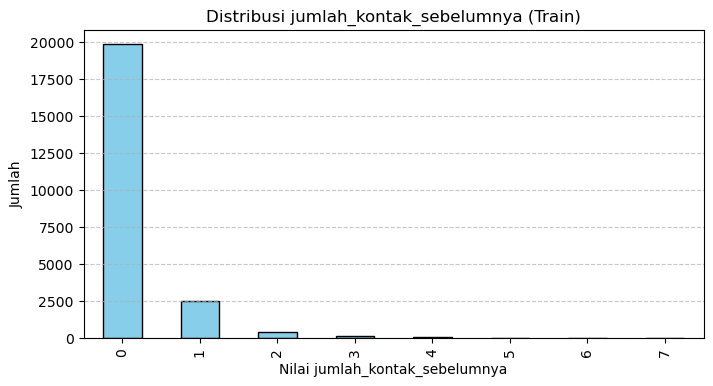

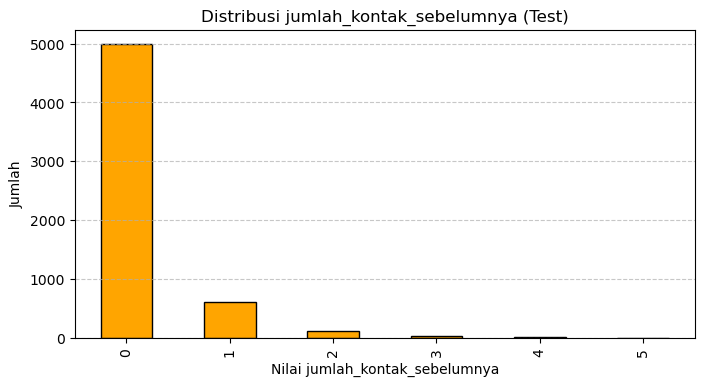

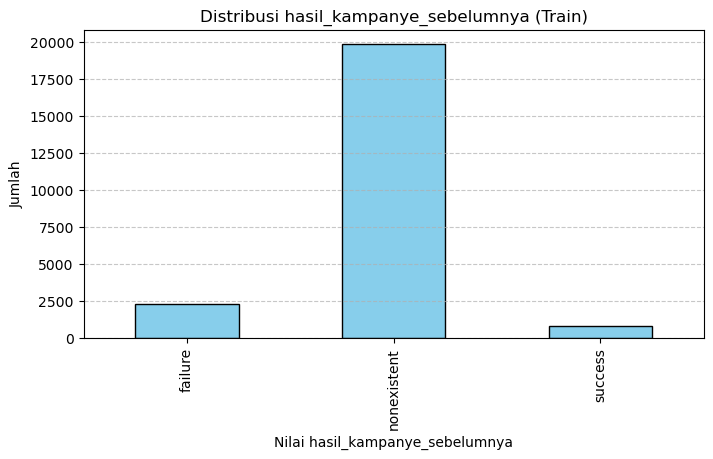

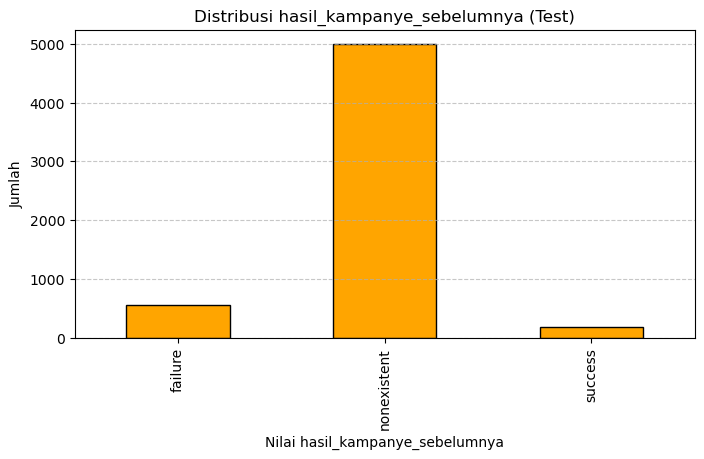

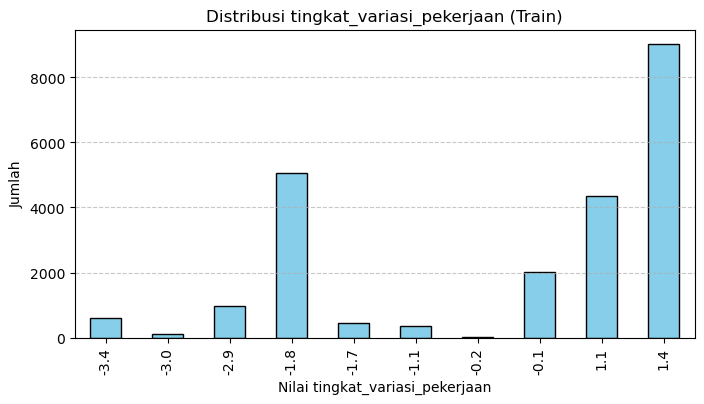

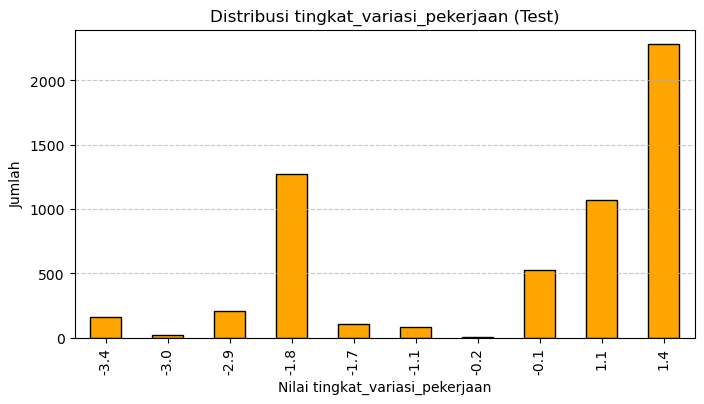

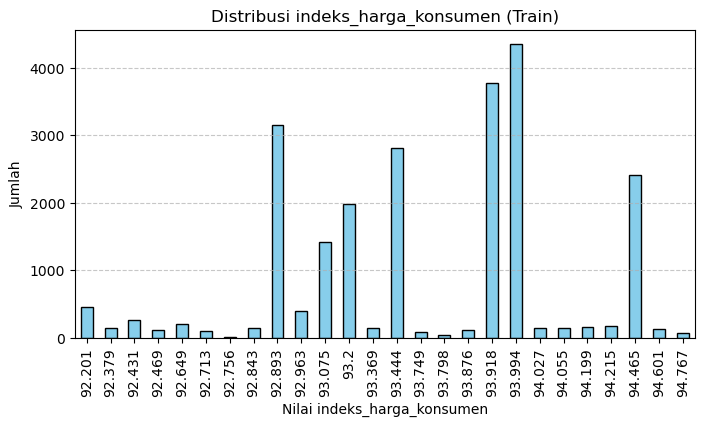

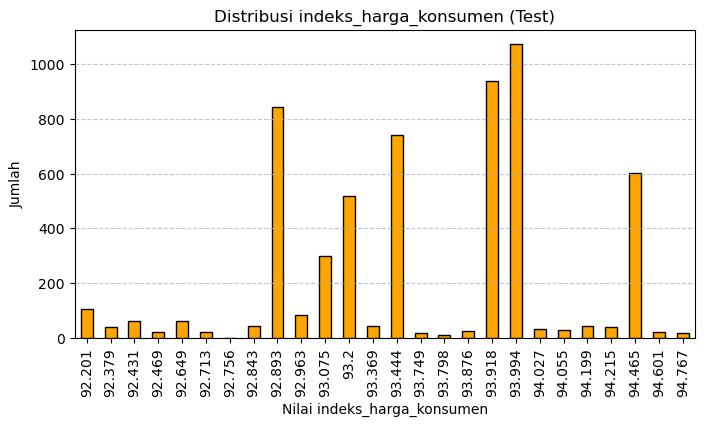

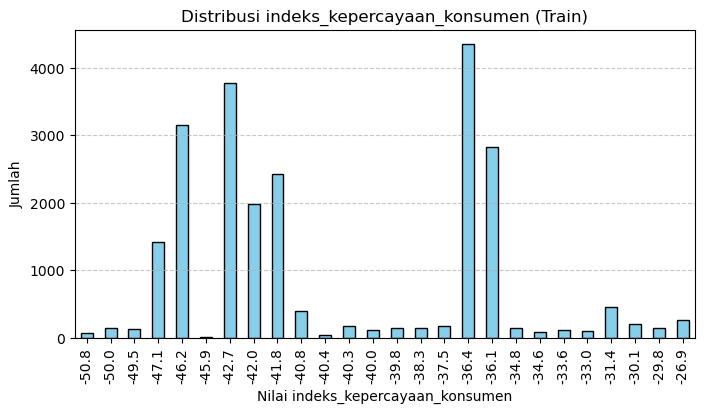

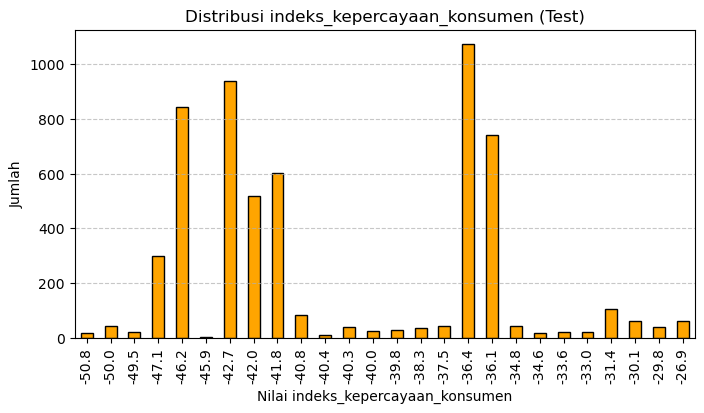

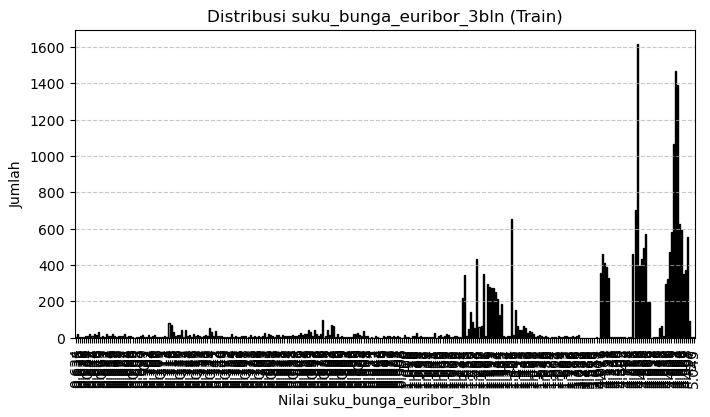

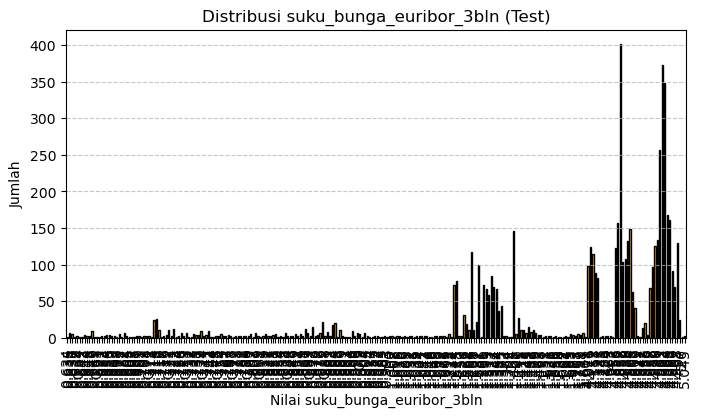

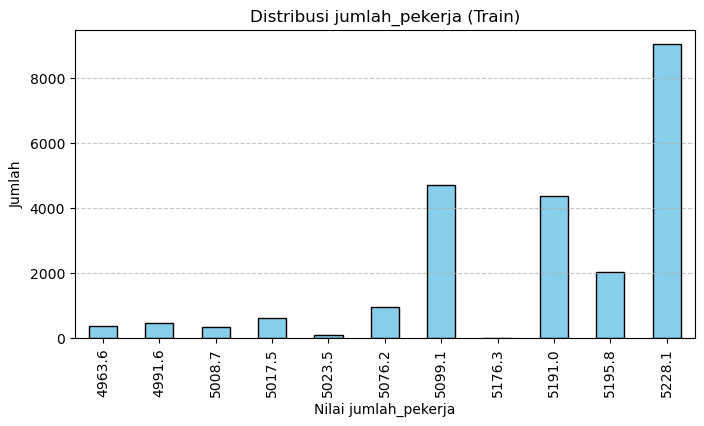

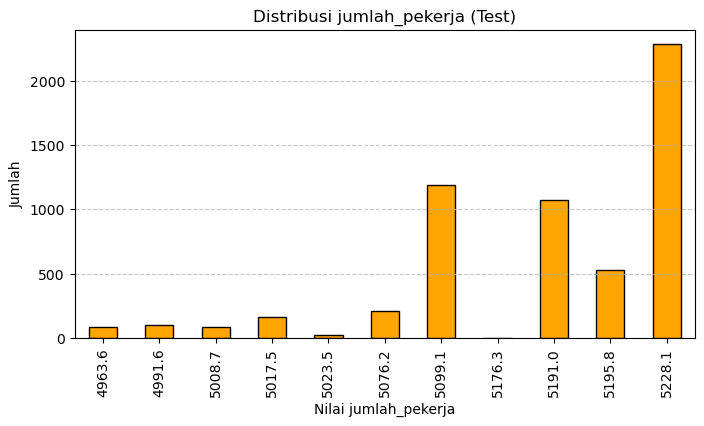

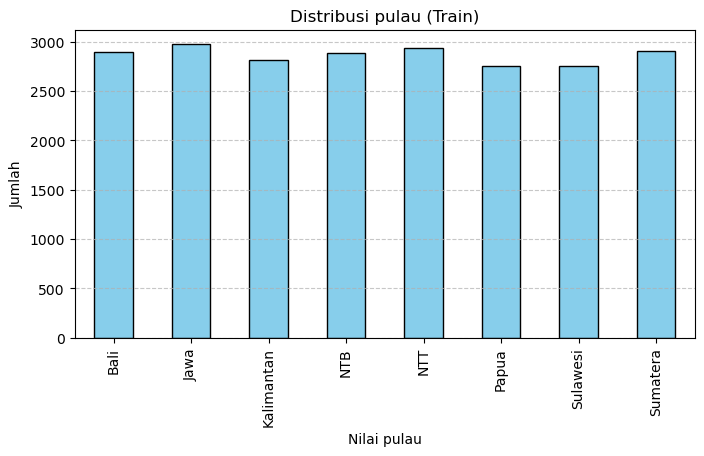

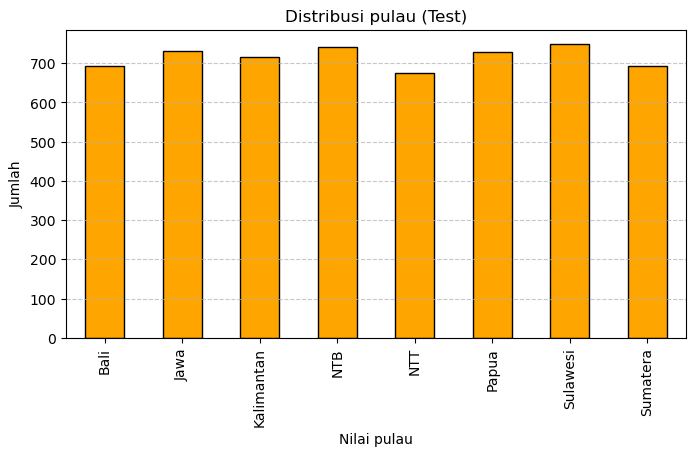

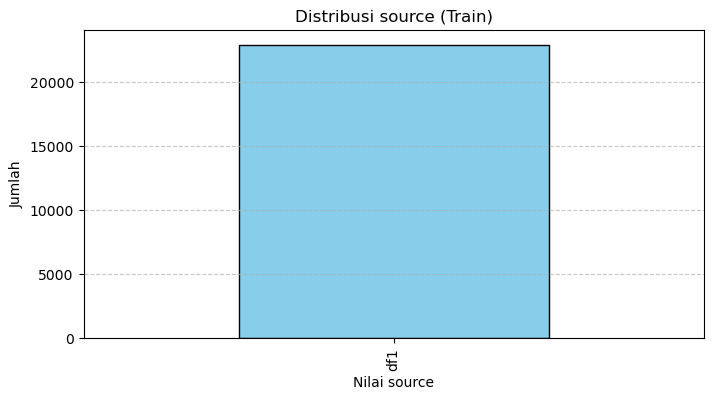

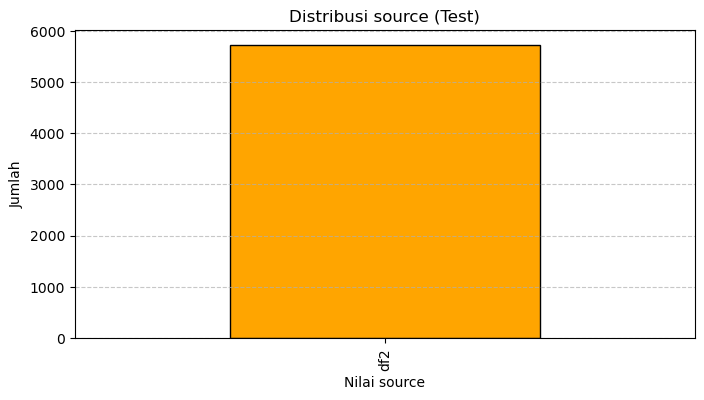

In [71]:
import matplotlib.pyplot as plt

# Pilih hanya kolom kategorikal (object) selain kolom target
categorical_cols = [col for col in df_train.columns if col != 'berlangganan_deposito']

for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        df_train[col].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Distribusi {col} (Train)')
        plt.xlabel(f'Nilai {col}')
        plt.ylabel('Jumlah')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        plt.figure(figsize=(8, 4))
        df_test[col].value_counts().sort_index().plot(kind='bar', color='orange', edgecolor='black')
        plt.title(f'Distribusi {col} (Test)')
        plt.xlabel(f'Nilai {col}')
        plt.ylabel('Jumlah')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


In [ ]:
%pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df_train, explorative=True)
profile.to_notebook_iframe()

`umur`
- Distribusi terbanyak ada di rentang umur 20–60 tahun.
- Saran: Buat kategori umur (misal: 20–30, 31–40, dst.), terus ubah jadi one hot encoding atau label encoding.

`pekerjaan`
- Tiga pekerjaan paling banyak: pekerja kasar, social media specialist, dan teknisi.
- Saran: Gunakan one hot encoding biar tiap jenis pekerjaan punya kolom sendiri.

`status_perkawinan`
- Mayoritas: menikah, lalu lajang, terakhir cerai.
- Ada nilai unknown.
- Saran:
  - Drop baris yang punya nilai unknown.
  - Jadikan label encoding

`pendidikan`
- Data cenderung meningkat di tingkatan pendidikan yang makin tinggi.
- Ada “TIDAK SEKOLAH” dan “unknown” (isinya 4,3%).
- Saran:
  - Drop untuk kategori “TIDAK SEKOLAH”.
  - “Unknown” masih bisa dipertimbangkan, tapi kalau mau aman bisa di-drop juga.
  - Gunakan label encoding untuk ngurutkan tingkatan pendidikan.

`gagal_bayar_sebelumnya`
- Nilai imbalance antara “no”, “yes”, dan “unknown”.
- Saran:
  - Drop baris dengan “yes” karena outlier.
  - Sisanya (“no” dan “unknown”) bisa diubah pakai label encoding.

`pinjaman_rumah`
- Distribusi stabil, nilai unknown cuma 579 data.
- Saran: Pakai one hot encoding.

`pinjaman_pribadi`
- Cukup signifikan korelasinya, tapi data imbalance.
- Sama seperti pinjaman rumah, unknown juga 579 data.
-Saran: Bandingin distribusinya dengan pinjaman rumah.

`jenis_kontak`
- Cuma ada dua kategori: cellular dan telephone, beda jumlahnya sekitar 6 ribu
- Saran: Tetap dipakai, bisa pakai label encoding karena kategorinya dikit.

`bulan_kontak_terakhir`
- Korelasi cukup tinggi, terutama bulan Mei yang paling dominan.
- Saran: Ubah ke label encoding (urut bulan juga bisa).

`hari_kontak_terakhir`
- Terdistribusi cukup merata.
- Saran: Ubah jadi numerik (misal: Senin = 1, Selasa = 2, dst.).

`jumlah_kontak_kampanye_ini`
- Data imbalance.
- Saran: Drop saja.

`hari_sejak_kontak_sebelumnya`
- Data sangat imbalance.
- Saran: Drop saja.

`jumlah_kontak_sebelumnya`
- Kebanyakan nilainya nol.
- Saran: Bisa dikategorikan (0, 1–2, >2) atau tetap pakai numerik tapi diuji korelasinya dulu.

`hasil_kampanye_sebelumnya`
- Imbalance, tapi high correlation.
- Saran: Tetap dipakai. Ubah ke label encoding.

`tingkat_variasi_pekerjaan`
- Banyak nilai minus, belum tahu jelas gunanya.
- Saran: Bisa dicoba dulu, kalau ternyata nggak pengaruh, tinggal drop belakangan.

`indeks_harga_konsumen`
- Korelasi tinggi.
- Saran: Dipakai langsung, udah dalam bentuk numerik.

`indeks_kepercayaan_konsumen`
- Sama kayak di atas, korelasi tinggi.
- Saran: Dipakai.

`suku_bunga_euribor_3bln`
- Korelasi tinggi.
- Saran: Dipakai.

`jumlah_pekerja`
- Korelasi tinggi juga.
- Saran: Tetap dipakai, diuji juga korelasinya nanti.

`pulau`
- Kategori geografis.
- Saran: Ubah ke one hot encoding.

`berlangganan_deposito`
- Ini kolom target prediksi.
- Saran: Jangan diubah, pake buat label klasifikasi.

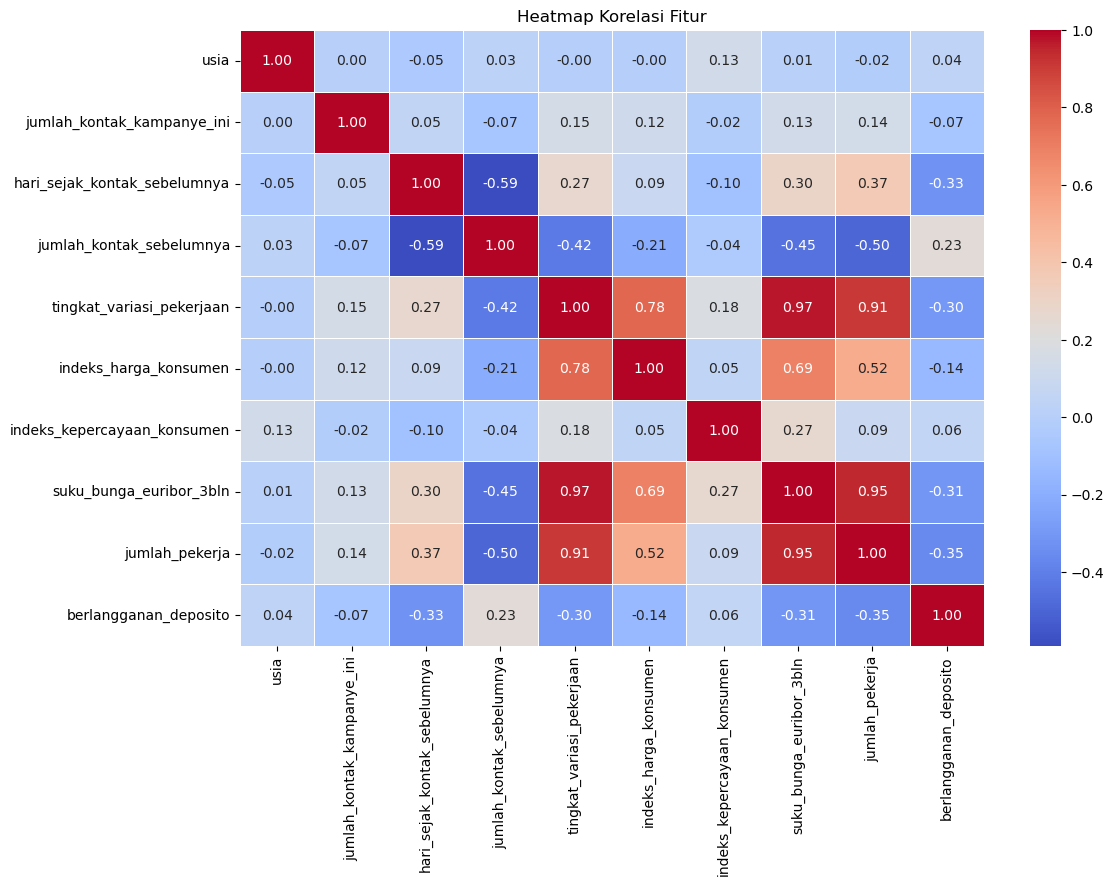

In [10]:
corr_matrix = df_train.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True)
plt.title("Heatmap Korelasi Fitur")
plt.show()


# Preprocessing

In [6]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Buat salinan agar tidak merusak original
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

# =========================
# 1. Transformasi Berdasarkan TRAIN SAJA
# =========================

# a. Usia → kategorisasi
usia_bins = [0, 19, 30, 40, 50, 60, 100]
usia_labels = ['<20', '20-30', '31-40', '41-50', '51-60', '60+']
usia_order = {'<20': 0, '20-30': 1, '31-40': 2, '41-50': 3, '51-60': 4, '60+': 5}

for df in [df_train_processed, df_test_processed]:
    df['usia_kategori'] = pd.cut(df['usia'], bins=usia_bins, labels=usia_labels, right=True, include_lowest=True)
    df['usia_kategori'] = df['usia_kategori'].map(usia_order).astype('Int64')

# b. Pekerjaan → one-hot
df_train_processed = pd.get_dummies(df_train_processed, columns=['pekerjaan'], prefix='job')
df_test_processed = pd.get_dummies(df_test_processed, columns=['pekerjaan'], prefix='job')
all_job_cols = list(set(df_train_processed.columns) | set(df_test_processed.columns))
for col in all_job_cols:
    if col.startswith('job_'):
        df_train_processed[col] = df_train_processed.get(col, 0).astype(int)
        df_test_processed[col] = df_test_processed.get(col, 0).astype(int)

# c. Status Perkawinan → drop unknown + mapping
status_map = {'lajang': 0, 'menikah': 1, 'cerai': 2}
for df in [df_train_processed, df_test_processed]:
    df.drop(df[df['status_perkawinan'] == 'unknown'].index, inplace=True)
    df['status_perkawinan'] = df['status_perkawinan'].map(status_map)

# d. Pendidikan → drop invalid values and encode
drop_edu = ['TIDAK SEKOLAH', 'unknown']
df_train_processed = df_train_processed[~df_train_processed['pendidikan'].isin(drop_edu)].copy()
le_pendidikan = LabelEncoder()
le_pendidikan.fit(df_train_processed['pendidikan'])
df_train_processed['pendidikan'] = le_pendidikan.transform(df_train_processed['pendidikan'])
df_test_processed = df_test_processed[~df_test_processed['pendidikan'].isin(drop_edu)].copy()
df_test_processed['pendidikan'] = le_pendidikan.transform(df_test_processed['pendidikan'])

# e. Gagal Bayar → drop "yes", encode sisanya
for df in [df_train_processed, df_test_processed]:
    df.drop(df[df['gagal_bayar_sebelumnya'] == 'yes'].index, inplace=True)
    df['gagal_bayar_sebelumnya'] = df['gagal_bayar_sebelumnya'].map({'no': 0, 'unknown': 1})

# f + g. Pinjaman → binary
for col in ['pinjaman_rumah', 'pinjaman_pribadi']:
    for df in [df_train_processed, df_test_processed]:
        df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

# h. Jenis Kontak → one-hot
df_train_processed = pd.get_dummies(df_train_processed, columns=['jenis_kontak'], prefix='kontak')
df_test_processed = pd.get_dummies(df_test_processed, columns=['jenis_kontak'], prefix='kontak')
all_kontak_cols = list(set(df_train_processed.columns) | set(df_test_processed.columns))
for col in all_kontak_cols:
    if col.startswith('kontak_'):
        df_train_processed[col] = df_train_processed.get(col, 0).astype(int)
        df_test_processed[col] = df_test_processed.get(col, 0).astype(int)

# i. Bulan → fit transform pakai encoder dari train
le_bulan = LabelEncoder()
le_bulan.fit(df_train_processed['bulan_kontak_terakhir'])
for df in [df_train_processed, df_test_processed]:
    df['bulan_kontak_terakhir'] = le_bulan.transform(df['bulan_kontak_terakhir'])

# j. Hari Kontak Terakhir
days_map = {'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5}
for df in [df_train_processed, df_test_processed]:
    df['hari_kontak_terakhir'] = df['hari_kontak_terakhir'].str.lower().map(days_map)

# k + l. Drop
drop_cols = ['jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya', 'kontak_telephone']
df_train_processed.drop(columns=drop_cols, inplace=True)
df_test_processed.drop(columns=drop_cols, inplace=True)

# m. Jumlah kontak sebelumnya → kategorisasi
jumlah_kontak_bins = [-1, 0, 2, df_train_processed['jumlah_kontak_sebelumnya'].max()]
jumlah_kontak_labels = ['rev 0', 'rev 1-2', 'rev >2']
rev_map = {'rev 0': 2, 'rev 1-2': 1, 'rev >2': 0}

for df in [df_train_processed, df_test_processed]:
    df['jumlah_kontak_kat'] = pd.cut(df['jumlah_kontak_sebelumnya'], bins=jumlah_kontak_bins, labels=jumlah_kontak_labels)
    df['jumlah_kontak_encoded'] = df['jumlah_kontak_kat'].map(rev_map).astype('Int64')
    df.drop(columns=['jumlah_kontak_sebelumnya', 'jumlah_kontak_kat'], inplace=True)

# n. Hasil Kampanye
le_kampanye = LabelEncoder()
le_kampanye.fit(df_train_processed['hasil_kampanye_sebelumnya'])
for df in [df_train_processed, df_test_processed]:
    df['hasil_kampanye_sebelumnya'] = le_kampanye.transform(df['hasil_kampanye_sebelumnya'])

# o. Pulau → one-hot
df_train_processed = pd.get_dummies(df_train_processed, columns=['pulau'], prefix='pulau')
df_test_processed = pd.get_dummies(df_test_processed, columns=['pulau'], prefix='pulau')
all_pulau_cols = list(set(df_train_processed.columns) | set(df_test_processed.columns))
for col in all_pulau_cols:
    if col.startswith('pulau_'):
        df_train_processed[col] = df_train_processed.get(col, 0).astype(int)
        df_test_processed[col] = df_test_processed.get(col, 0).astype(int)

# p. Making new feature from column suku_bunga_euribor_3bln
col_to_bin = 'suku_bunga_euribor_3bln'
num_bins = 13
bin_edges = pd.cut(df_train_processed[col_to_bin], bins=num_bins, include_lowest=True, retbins=True)[1]
df_train_processed['bin_suku_bunga'] = pd.cut(df_train_processed[col_to_bin], bins=bin_edges, include_lowest=True).cat.codes
df_test_processed['bin_suku_bunga'] = pd.cut(df_test_processed[col_to_bin], bins=bin_edges, include_lowest=True).cat.codes

# Final drop kolom sensitif
for df in [df_train_processed, df_test_processed]:
    df.drop(columns=['usia_kategori'], inplace=True)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Gabungkan data
df_train['source'] = 'df1'
df_test['source'] = 'df2'
df_all = pd.concat([df_train, df_test], ignore_index=True)

# 2. Preprocessing
def convert_cat_to_num(df, column_name, mapping_dict=None, drop_unknown=True):
    if mapping_dict is not None:
        if drop_unknown:
            mask = df[column_name].isin(mapping_dict)
            df.drop(df.index[~mask], inplace=True)
        df[column_name] = df[column_name].map(mapping_dict).astype("int64")
    else:
        df[column_name], unique_value = pd.factorize(df[column_name])
        df[column_name] = df[column_name].astype("int64")

        # # Print mapping
        # print(f"Mapping for column '{column_name}':")
        # for i, value in enumerate(unique_value):
        #     print(f"  {value} → {i}")

# a. Usia → kategorisasi + label encoding (tambahkan kategori <20 jadi 0, 20-30 jadi 1, dst.)
df_all['usia_kategori'] = pd.cut(
    df_all['usia'],
    bins=[0, 19, 30, 40, 50, 60, 100],
    labels=['<20', '20-30', '31-40', '41-50', '51-60', '60+']
)
usia_order = {'<20': 0, '20-30': 1, '31-40': 2, '41-50': 3, '51-60': 4, '60+': 5}
convert_cat_to_num(df_all, 'usia_kategori', mapping_dict=usia_order)

# b. Pekerjaan → one hot
df_all = pd.get_dummies(df_all, columns=['pekerjaan'], prefix='job')
# df_all.drop(columns=['job_unknown'], inplace=True)

# c. Status Perkawinan → drop unknown, label encoding (custom order)
# status_map = {'menikah': 'lajang' 'cerai' 'unknown'} # No added value
convert_cat_to_num(df_all, 'status_perkawinan')
# df_all.drop(columns=['job_unknown'], inplace=True)

# # d. Pendidikan → drop “TIDAK SEKOLAH” dan “unknown”
convert_cat_to_num(df_all, 'pendidikan')
# df_all = pd.get_dummies(df_all, columns=['pendidikan'], prefix='strata') # No added value

# e. Gagal Bayar Sebelumnya → drop “yes”, encode sisanya (no=0, unknown=1)
# df_all = df_all[df_all['gagal_bayar_sebelumnya'] != 'yes']
# df_all['gagal_bayar_sebelumnya'] = df_all['gagal_bayar_sebelumnya'].map({'no': 0, 'unknown': 1})
convert_cat_to_num(df_all, 'gagal_bayar_sebelumnya')

# f. Pinjaman Rumah → biner (yes=1, lainnya=0)
convert_cat_to_num(df_all, 'pinjaman_rumah')

# g. Pinjaman Pribadi → biner (yes=1, lainnya=0)
convert_cat_to_num(df_all, 'pinjaman_pribadi')

# h. Jenis Kontak → one hot
convert_cat_to_num(df_all, 'jenis_kontak')

# i. Bulan Kontak Terakhir → label encoding
month_map = {'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul' : 7, 'aug': 8, 'sep': 9, 'nov': 10, 'oct': 11, 'dec': 12}
convert_cat_to_num(df_all, 'bulan_kontak_terakhir', mapping_dict=month_map)

# j. Hari Kontak Terakhir → encode manual
days_map = {'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5}
convert_cat_to_num(df_all, 'hari_kontak_terakhir', mapping_dict=days_map)

# # k. Jumlah Kontak Kampanye Ini → drop
df_all.drop(columns=['jumlah_kontak_kampanye_ini'], inplace=True)

# l. Hari Sejak Kontak Sebelumnya → drop
df_all.drop(columns=['hari_sejak_kontak_sebelumnya'], inplace=True)

# m. Jumlah Kontak Sebelumnya → kategorisasi + one hot
df_all['jumlah_kontak_sebelumnya_kat'] = pd.cut(
    df_all['jumlah_kontak_sebelumnya'],
    bins=[-1, 0, 2, df_all['jumlah_kontak_sebelumnya'].max()],
    labels=['0', '1-2', '>2']
)
df_all.drop(columns=['jumlah_kontak_sebelumnya'], inplace=True)
convert_cat_to_num(df_all, 'jumlah_kontak_sebelumnya_kat')

# n. Hasil Kampanye Sebelumnya → label encoding
convert_cat_to_num(df_all, 'hasil_kampanye_sebelumnya')

# o. Pulau → one hot encoding
convert_cat_to_num(df_all, 'pulau')

# Select all boolean columns
bool_cols = df_all.select_dtypes(include='bool').columns
df_all[bool_cols] = df_all[bool_cols].astype(int)

# 3. Pisahkan kembali
df_train_processed = df_all[df_all['source'] == 'df1'].drop(columns=['source'])
df_test_processed = df_all[df_all['source'] == 'df2'].drop(columns=['source'])
df_test_processed.drop(inplace=True, columns=['berlangganan_deposito'])

In [8]:
df_test.customer_number

0       445420
1       585604
2       888824
3       816820
4       542716
         ...  
5724    782072
5725    116371
5726    773759
5727    612330
5728    986050
Name: customer_number, Length: 5729, dtype: int64

In [9]:
df_train_processed.drop(columns=["customer_number", "hari_kontak_terakhir"], inplace=True)
df_test_processed.drop(columns=["hari_kontak_terakhir"], inplace=True)

In [11]:
df_train_processed.iloc[:10, :15]

,usia,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,63,0,0,0,0,0,0,7,0,-1.7,94.215,-40.3,0.885,4991.6,0
1,43,0,0,0,0,0,0,10,0,-0.1,93.200,-42.0,4.021,5195.8,1
2,29,1,0,0,0,1,0,7,0,1.4,93.918,-42.7,4.958,5228.1,0
3,40,0,1,0,1,0,1,5,0,1.1,93.994,-36.4,4.859,5191.0,2
4,40,1,0,0,1,0,0,8,0,1.4,93.444,-36.1,4.964,5228.1,3
5,34,2,0,0,0,0,1,5,0,1.1,93.994,-36.4,4.856,5191.0,2
6,31,1,0,0,0,1,0,7,0,1.4,93.918,-42.7,4.957,5228.1,4
7,29,0,1,0,1,0,1,5,0,1.1,93.994,-36.4,4.864,5191.0,2
8,37,2,0,0,2,2,1,5,0,1.1,93.994,-36.4,4.857,5191.0,2
9,30,1,1,0,0,0,0,7,0,1.4,93.918,-42.7,4.963,5228.1,1


In [12]:
df_train_processed.jumlah_pekerja.unique()

array([4991.6, 5195.8, 5228.1, 5191. , 4963.6, 5099.1, 5017.5, 5076.2,
       5008.7, 5023.5, 5176.3])

In [13]:
df_train_processed.iloc[:10, :15]

,usia,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,63,0,0,0,0,0,0,7,0,-1.7,94.215,-40.3,0.885,4991.6,0
1,43,0,0,0,0,0,0,10,0,-0.1,93.200,-42.0,4.021,5195.8,1
2,29,1,0,0,0,1,0,7,0,1.4,93.918,-42.7,4.958,5228.1,0
3,40,0,1,0,1,0,1,5,0,1.1,93.994,-36.4,4.859,5191.0,2
4,40,1,0,0,1,0,0,8,0,1.4,93.444,-36.1,4.964,5228.1,3
5,34,2,0,0,0,0,1,5,0,1.1,93.994,-36.4,4.856,5191.0,2
6,31,1,0,0,0,1,0,7,0,1.4,93.918,-42.7,4.957,5228.1,4
7,29,0,1,0,1,0,1,5,0,1.1,93.994,-36.4,4.864,5191.0,2
8,37,2,0,0,2,2,1,5,0,1.1,93.994,-36.4,4.857,5191.0,2
9,30,1,1,0,0,0,0,7,0,1.4,93.918,-42.7,4.963,5228.1,1


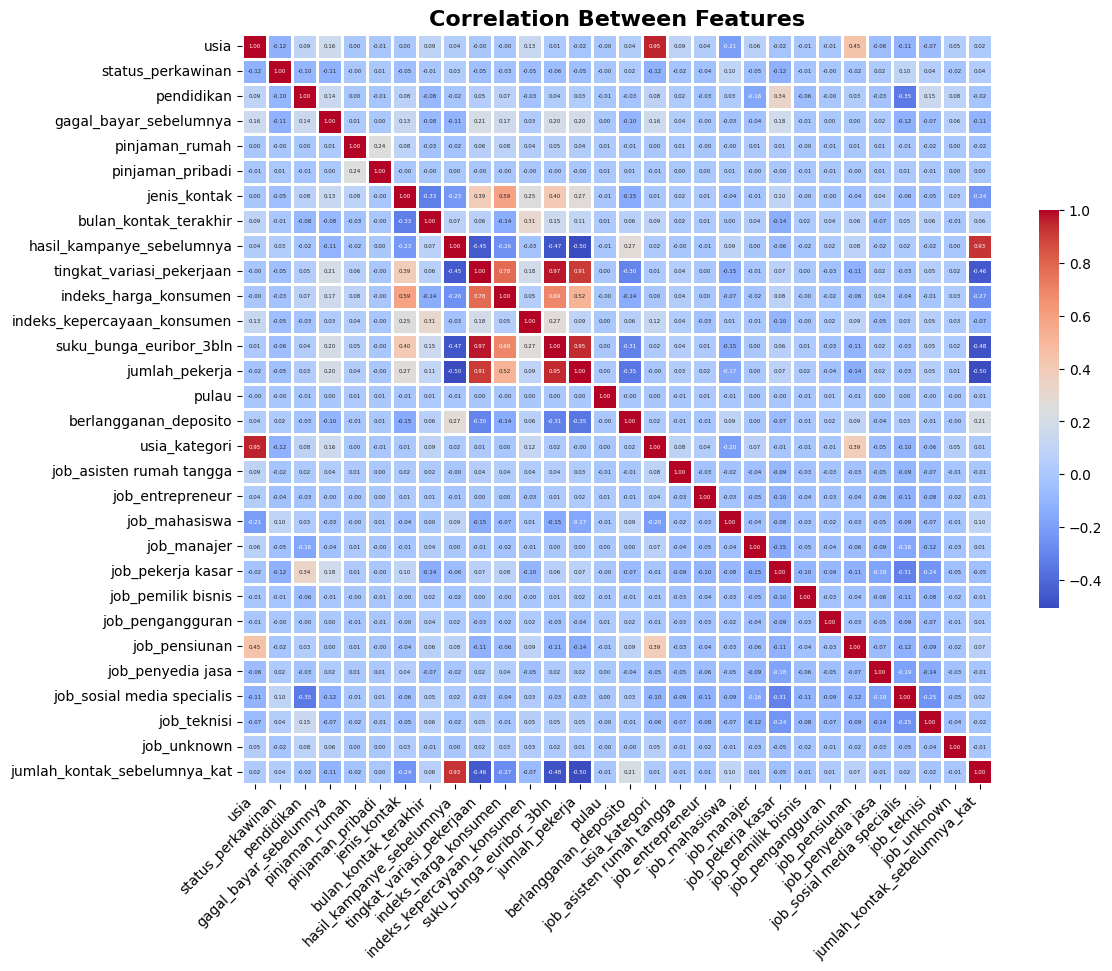

In [19]:
# Calculate correlation
correlation_matrix = df_train_processed.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=1,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.5},
    annot_kws={"size": 4}
)

plt.title("Correlation Between Features", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
# plt.savefig("grafik_hd.png", dpi=300, bbox_inches="tight")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

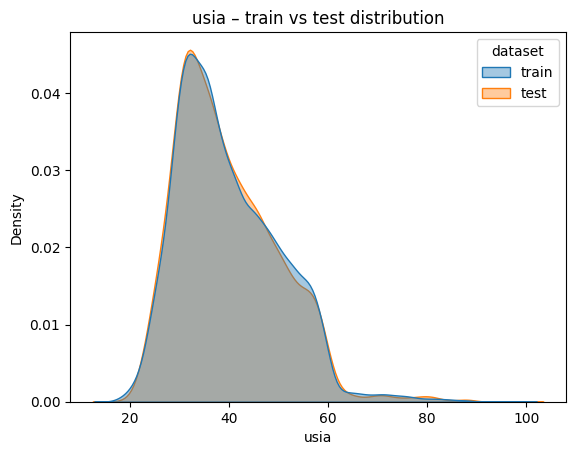

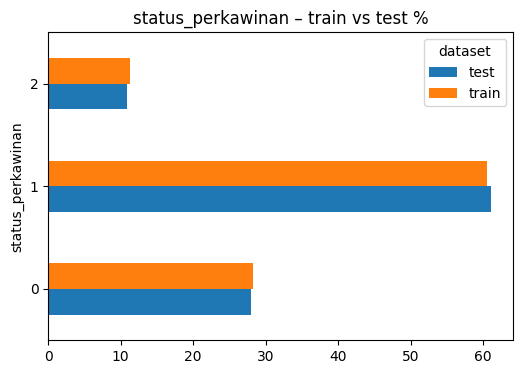

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

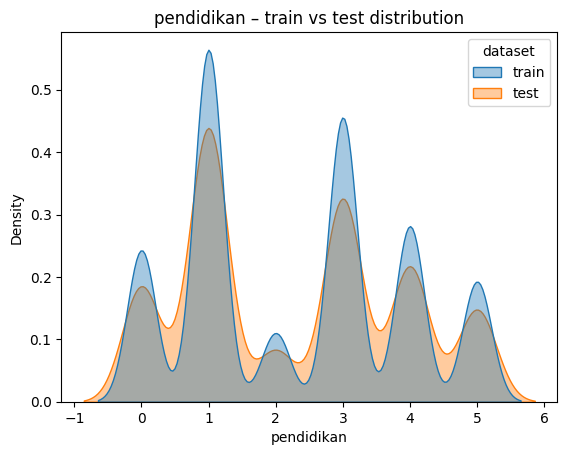

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

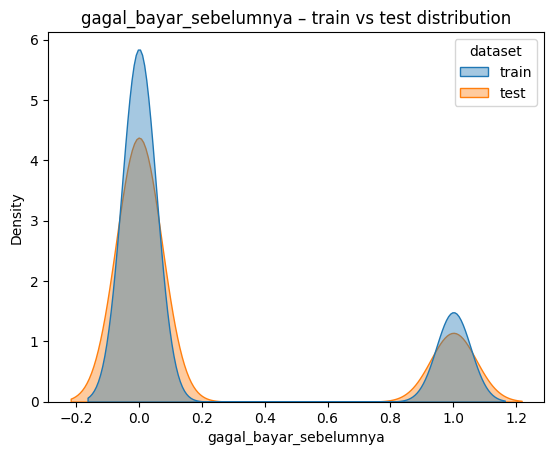

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

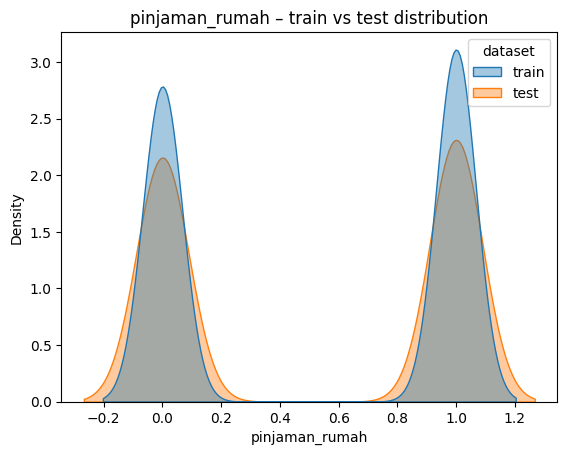

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

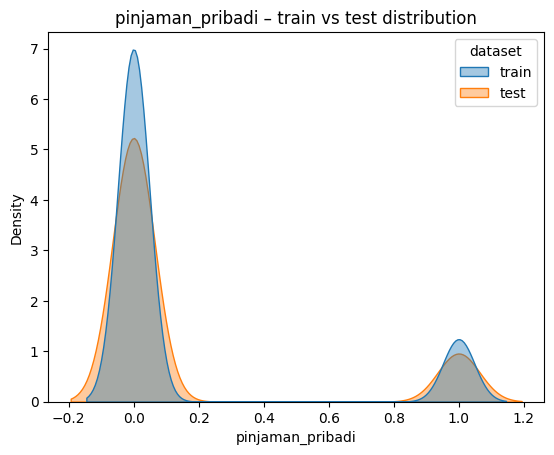

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

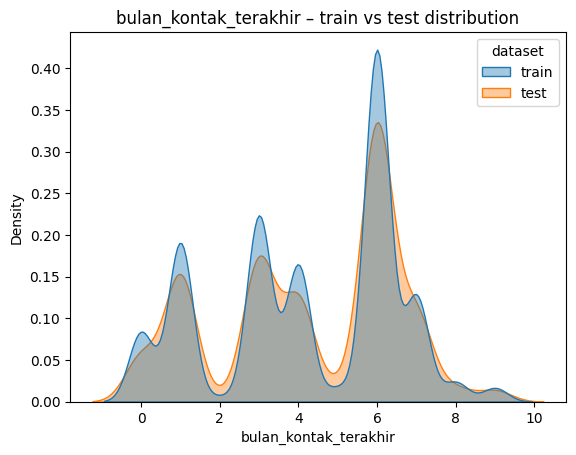

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

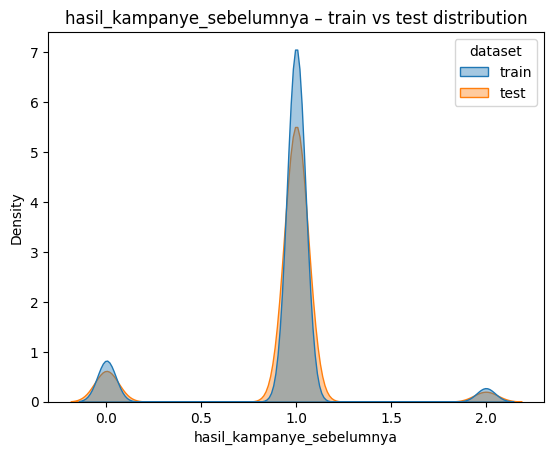

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

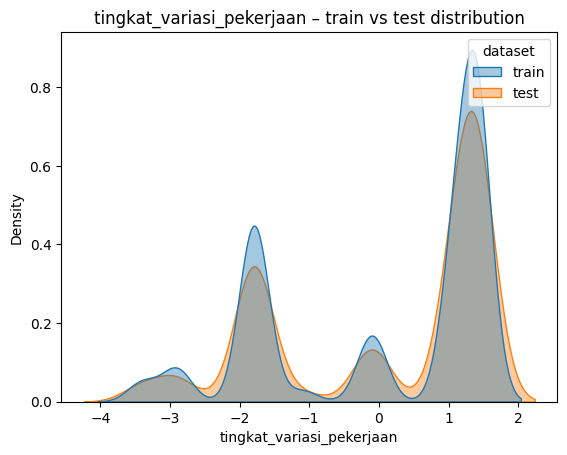

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

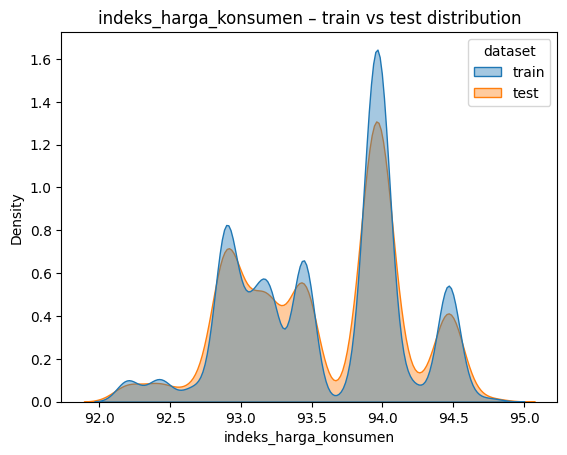

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

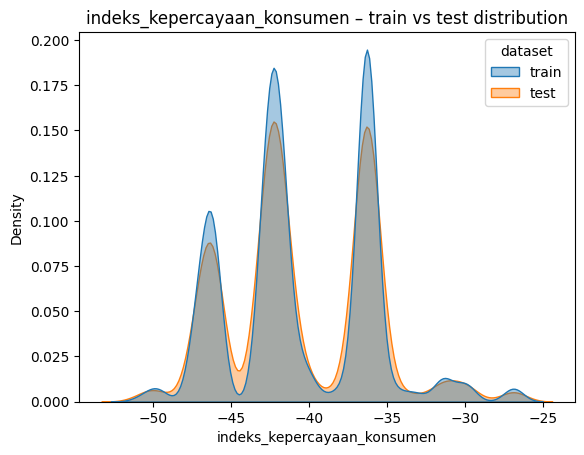

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

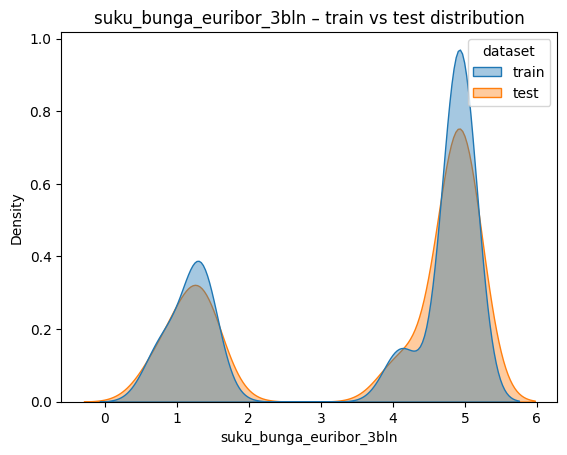

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

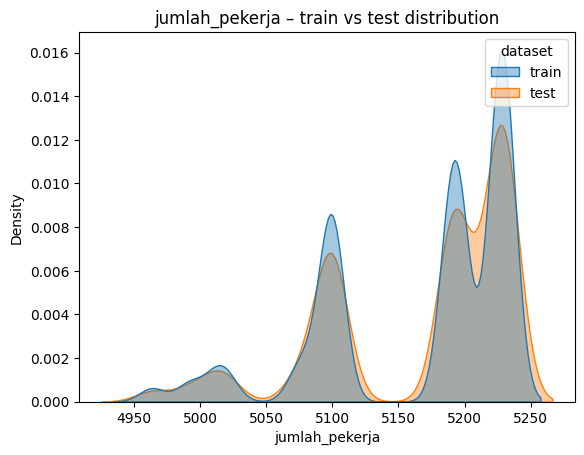

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

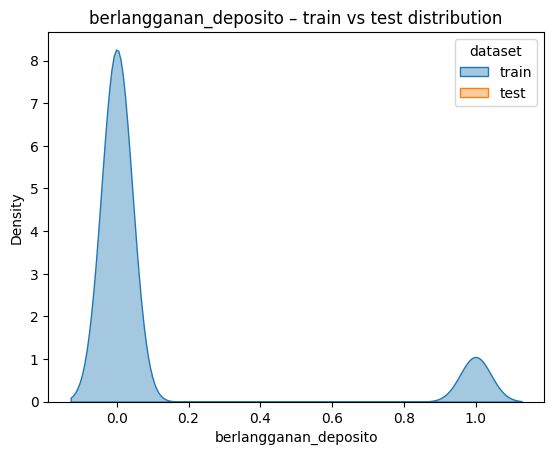

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

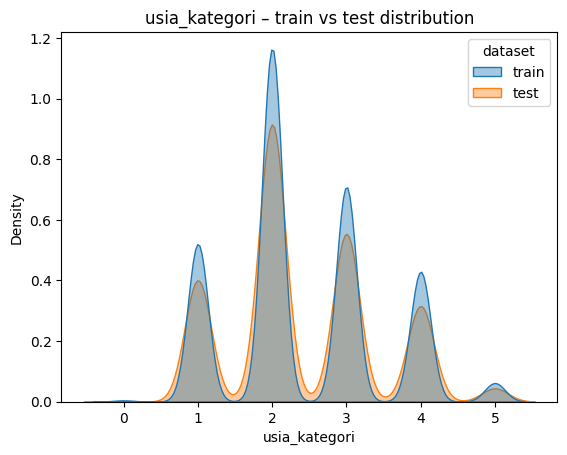

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

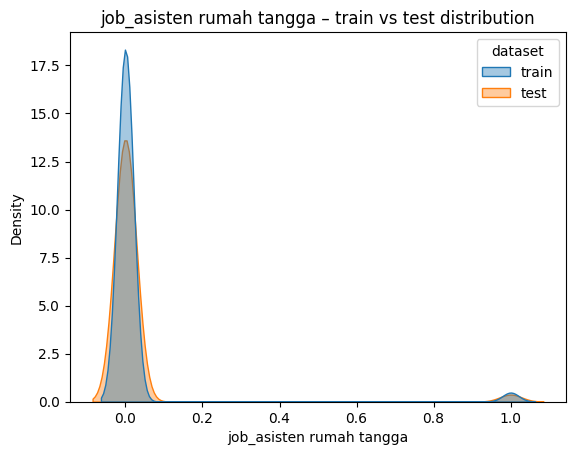

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

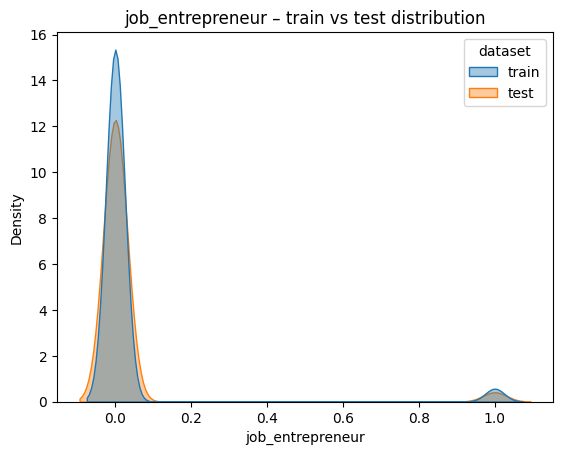

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

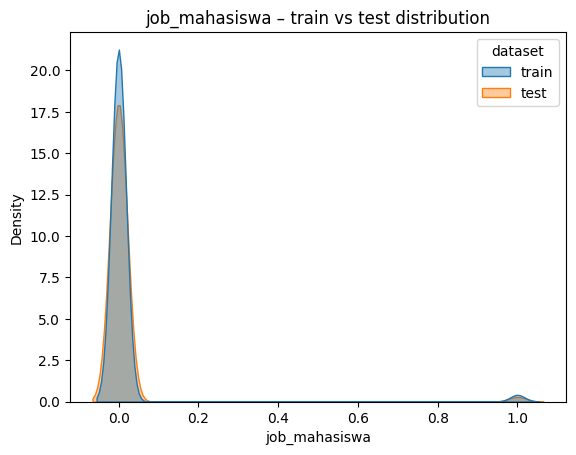

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

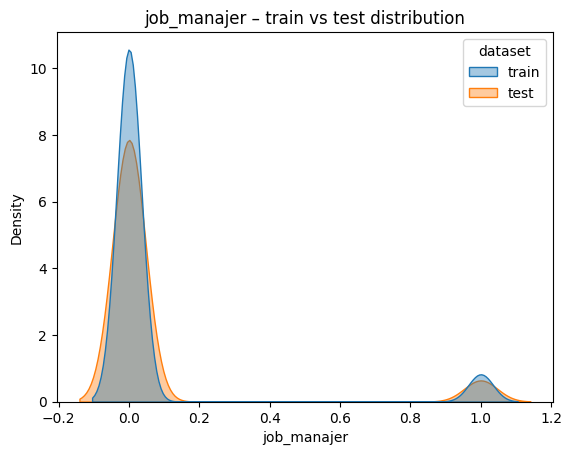

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

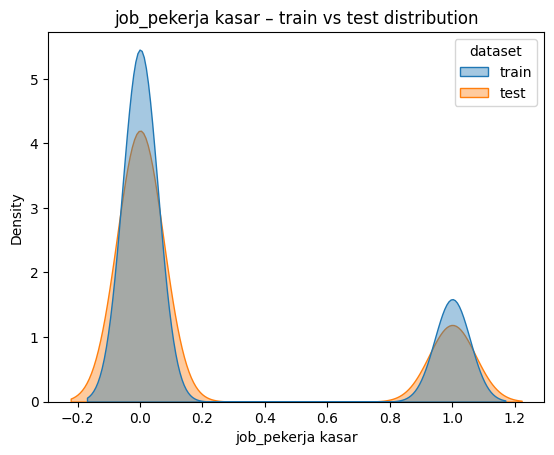

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

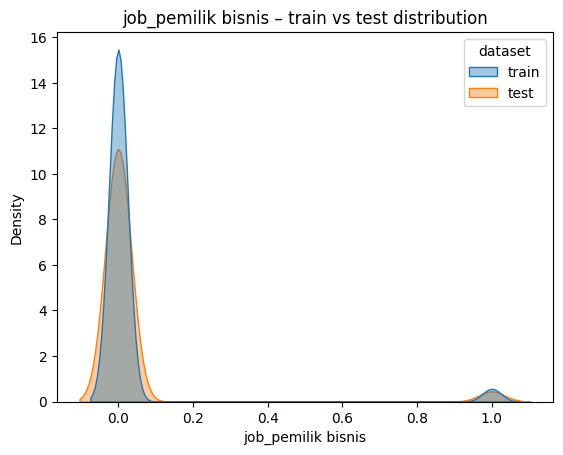

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

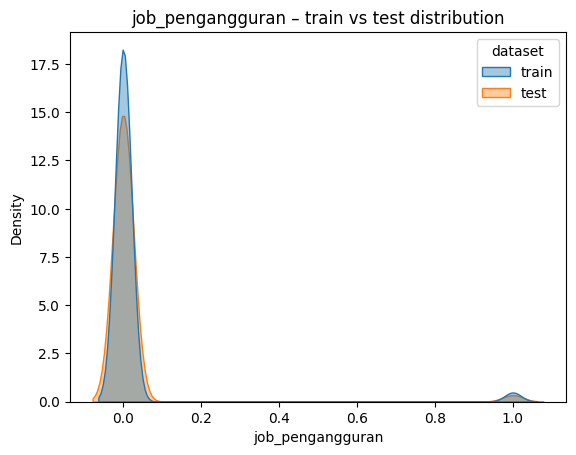

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

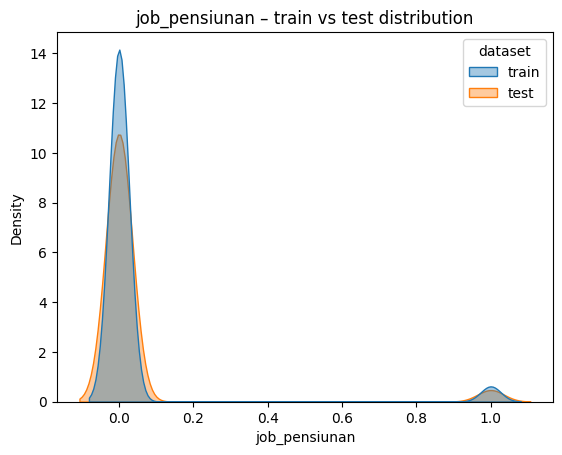

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

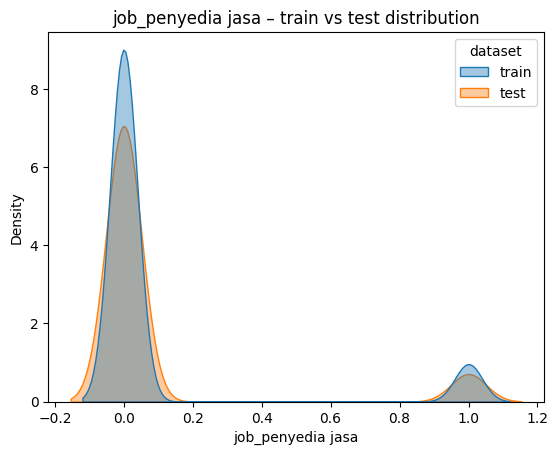

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

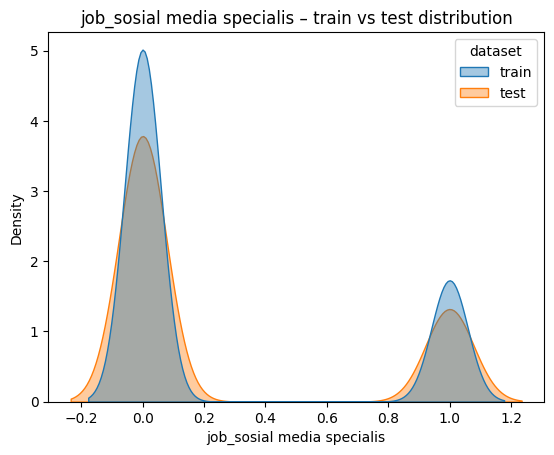

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

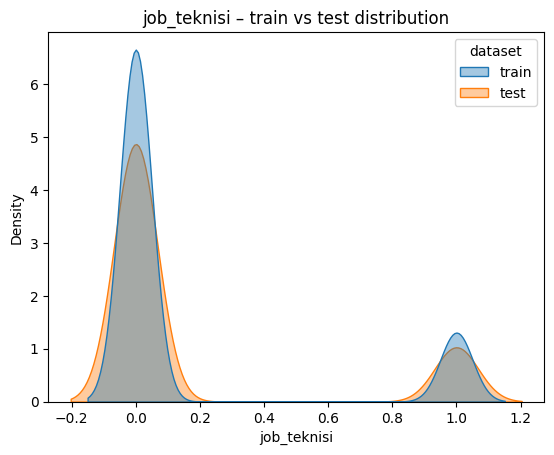

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

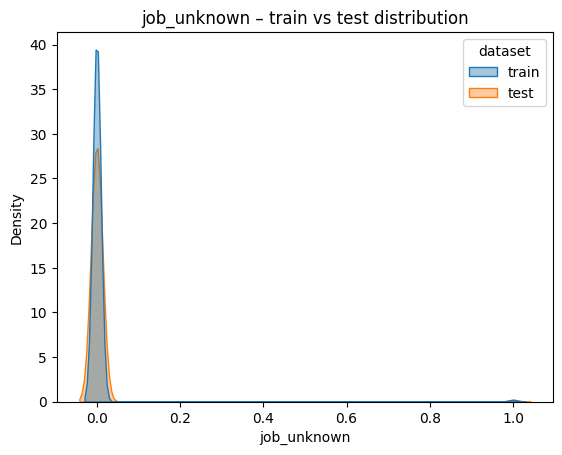

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

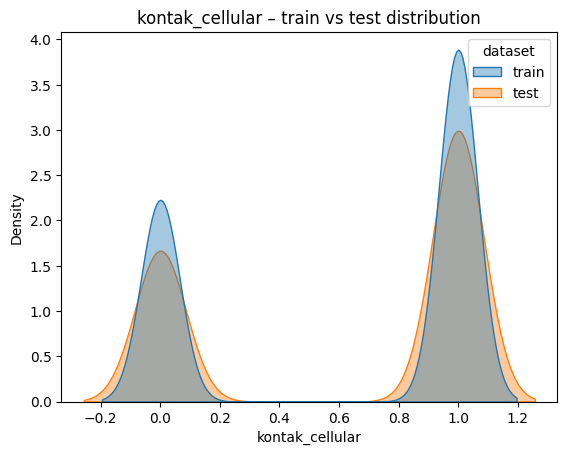

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

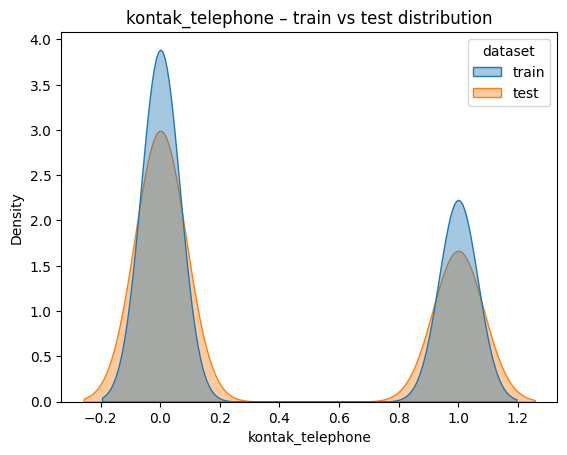

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

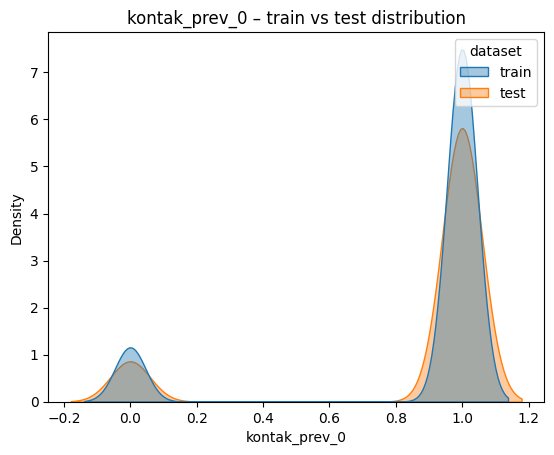

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

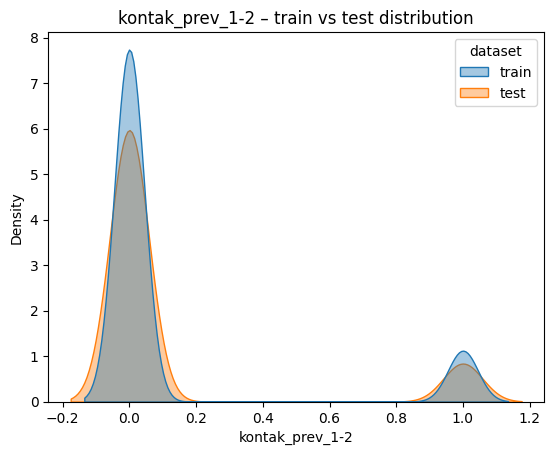

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

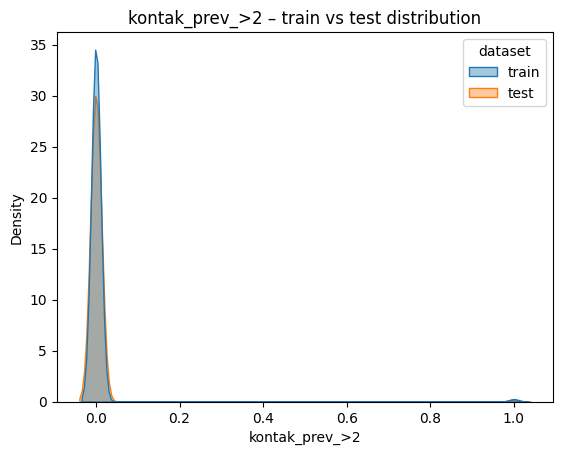

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

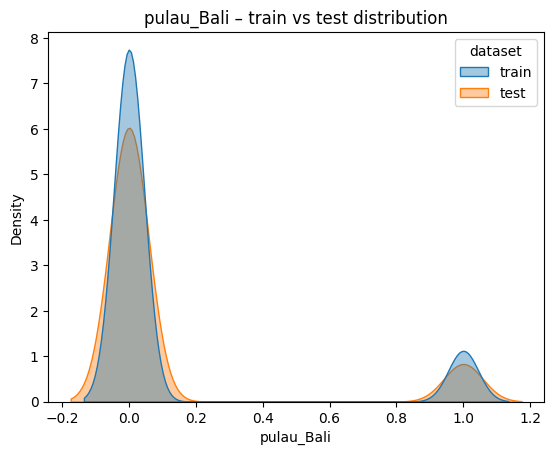

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

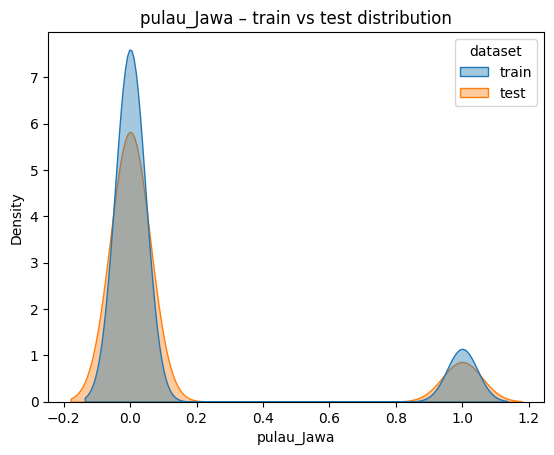

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

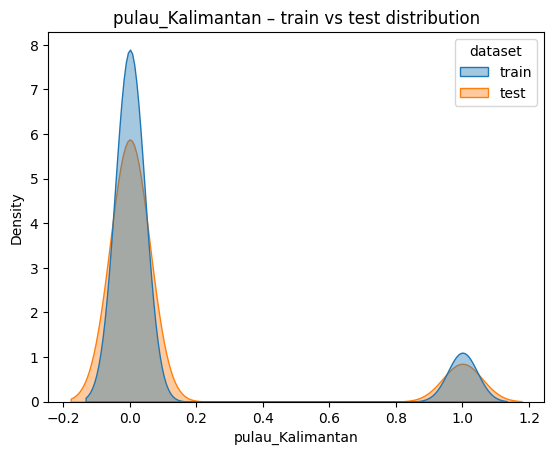

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

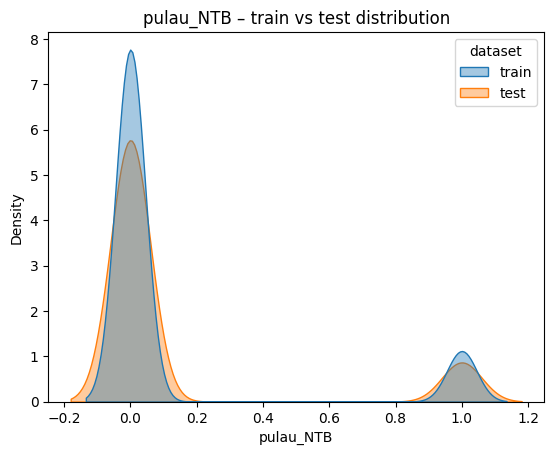

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

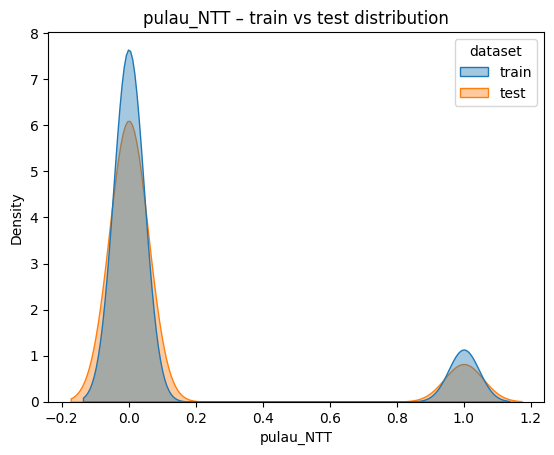

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

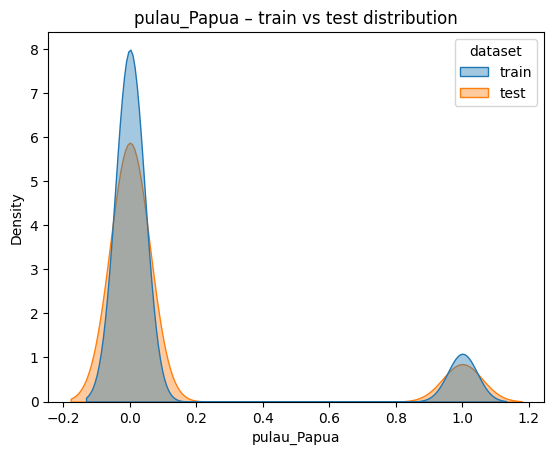

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

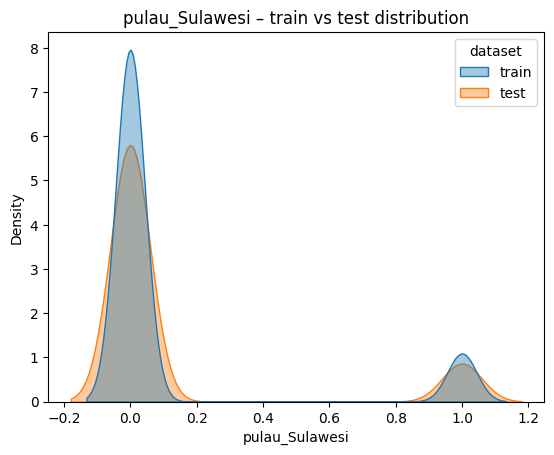

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

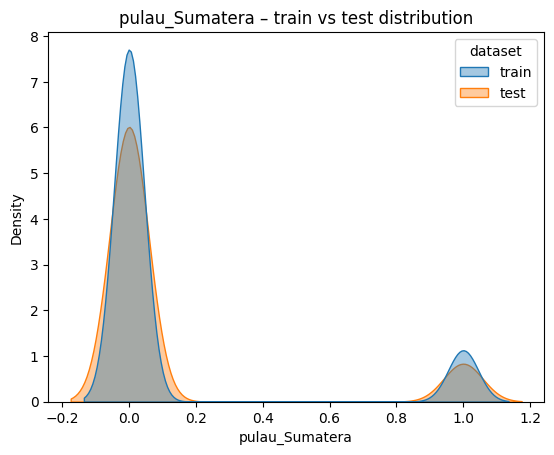

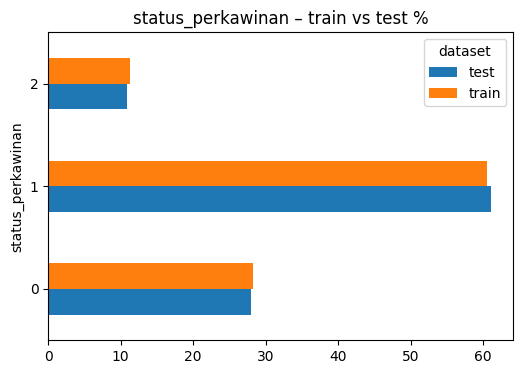

In [25]:
num_cols = df_train_processed.select_dtypes(include = ["int64", "float64"]).columns.tolist()
compare_cols = num_cols + ["status_perkawinan"]
selected_cols = list(dict.fromkeys(compare_cols + ["dataset"]))
train_tag = df_train_processed.assign(dataset="train")[selected_cols]
test_tag  = df_test_processed.assign(dataset="test")[[col for col in selected_cols if col != "berlangganan_deposito"]]
combo = pd.concat([train_tag, test_tag], axis = 0)

for col in compare_cols:
    if col == "status_perkawinan":
        ct = pd.crosstab(combo[col], combo["dataset"], normalize = "columns") * 100
        ct.plot.barh(figsize = (6, 4), stacked=False, title = f"{col} – train vs test %")
        plt.show()
    else:
        sns.kdeplot(data = combo, x = col, hue = "dataset", fill = True, common_norm = False, alpha = 0.4)
        plt.title(f"{col} – train vs test distribution"); plt.show()

In [26]:
import pandas as pd
import scipy.stats as stats

def chi_square_all_categories(df, target_col):
    categorical_cols = df.select_dtypes(include=['object']).columns
    results = []

    for col in categorical_cols:
        contingency_table = pd.crosstab(df[col], df[target_col])
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        significance_level = 0.05
        result = "Ada hubungan signifikan" if p < significance_level else "Tidak ada hubungan signifikan"

        results.append({"Kolom": col, "Chi-Square": chi2, "p-value": p, "Kesimpulan": result})

    return pd.DataFrame(results)


chi_square_results = chi_square_all_categories(df_train,"berlangganan_deposito")
print(chi_square_results)


                        Kolom   Chi-Square        p-value  \
0                   pekerjaan   527.664903  4.014069e-106   
1           status_perkawinan    57.356920   2.156349e-12   
2                  pendidikan   106.996549   3.851686e-20   
3      gagal_bayar_sebelumnya   226.514305   6.501949e-50   
4              pinjaman_rumah     2.548518   2.796381e-01   
5            pinjaman_pribadi     0.921314   6.308691e-01   
6                jenis_kontak   508.629124  1.260314e-112   
7       bulan_kontak_terakhir  1603.571962   0.000000e+00   
8        hari_kontak_terakhir    12.517538   1.389038e-02   
9   hasil_kampanye_sebelumnya  2353.906221   0.000000e+00   
10                      pulau     6.420646   4.915779e-01   
11                     source     0.000000   1.000000e+00   

                       Kesimpulan  
0         Ada hubungan signifikan  
1         Ada hubungan signifikan  
2         Ada hubungan signifikan  
3         Ada hubungan signifikan  
4   Tidak ada hubungan sig

In [21]:
df_train_processed.columns

Index(['usia', 'status_perkawinan', 'pendidikan', 'gagal_bayar_sebelumnya',
       'pinjaman_rumah', 'pinjaman_pribadi', 'bulan_kontak_terakhir',
       'hasil_kampanye_sebelumnya', 'tingkat_variasi_pekerjaan',
       'indeks_harga_konsumen', 'indeks_kepercayaan_konsumen',
       'suku_bunga_euribor_3bln', 'jumlah_pekerja', 'berlangganan_deposito',
       'usia_kategori', 'job_asisten rumah tangga', 'job_entrepreneur',
       'job_mahasiswa', 'job_manajer', 'job_pekerja kasar',
       'job_pemilik bisnis', 'job_pengangguran', 'job_pensiunan',
       'job_penyedia jasa', 'job_sosial media specialis', 'job_teknisi',
       'job_unknown', 'kontak_cellular', 'kontak_telephone', 'kontak_prev_0',
       'kontak_prev_1-2', 'kontak_prev_>2', 'pulau_Bali', 'pulau_Jawa',
       'pulau_Kalimantan', 'pulau_NTB', 'pulau_NTT', 'pulau_Papua',
       'pulau_Sulawesi', 'pulau_Sumatera'],
      dtype='object')

In [20]:
df_train_processed.columns

Index(['usia', 'status_perkawinan', 'pendidikan', 'gagal_bayar_sebelumnya',
       'pinjaman_rumah', 'pinjaman_pribadi', 'jenis_kontak',
       'bulan_kontak_terakhir', 'hasil_kampanye_sebelumnya',
       'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen',
       'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln',
       'jumlah_pekerja', 'pulau', 'berlangganan_deposito', 'usia_kategori',
       'job_asisten rumah tangga', 'job_entrepreneur', 'job_mahasiswa',
       'job_manajer', 'job_pekerja kasar', 'job_pemilik bisnis',
       'job_pengangguran', 'job_pensiunan', 'job_penyedia jasa',
       'job_sosial media specialis', 'job_teknisi', 'job_unknown',
       'jumlah_kontak_sebelumnya_kat'],
      dtype='object')

In [ ]:
df_train_filtered = df_train_processed.copy()

# Function for Modelling

In [16]:
from sklearn.model_selection import train_test_split

X = df_train_filtered.drop(columns=["berlangganan_deposito"])
y = df_train_filtered["berlangganan_deposito"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

def auc_score(y_test, y_pred):
  auc_score = roc_auc_score(y_test, y_pred)
  return auc_score

def curve_plot_auc(y_test, y_pred, auc_score, title_name):
  fpr, tpr, _ = roc_curve(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}", color="blue")
  plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title(f"ROC Curve ({title_name})")
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

def inverse_number(scaled_data, scaler):
  inverse_data = scaler.inverse_transform(scaled_data)
  return inverse_data

# Modelling

AUC Score (Logistic Regression Model): 0.7252


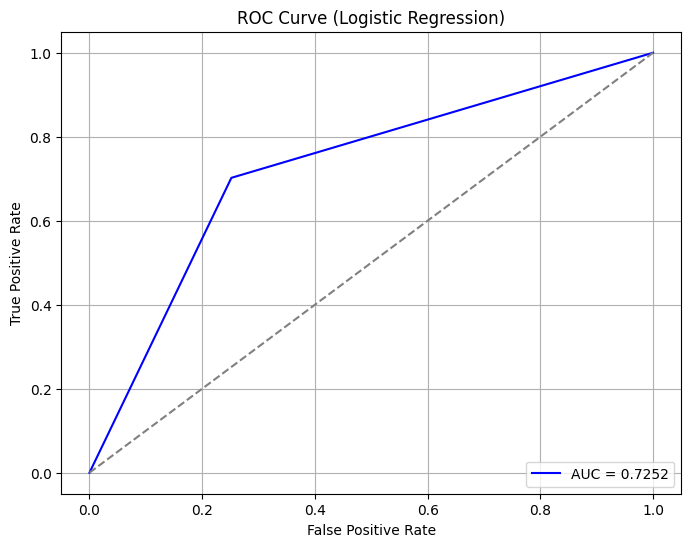

In [39]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

def fitting_logreg_model(X_train, X_test, y_train, y_test):
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  model = LogisticRegression(solver="liblinear")
  model.fit(X_train, y_train)
  y_pred_prob = model.predict_proba(X_test)[:, 1]
  y_pred_class = (y_pred_prob >= 0.095).astype(int)

  auc_score_num = auc_score(y_test, y_pred_class)
  print(f"AUC Score (Logistic Regression Model): {auc_score_num:.4f}")
  curve_plot_auc(y_test, y_pred_class, auc_score_num, "Logistic Regression")

  return model

logreg_model = fitting_logreg_model(X_train, X_test, y_train, y_test)

# TabNet

In [21]:
%pip install pytorch-tabnet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.9 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import numpy as np
from sklearn.model_selection import KFold
from pytorch_tabnet.tab_model import TabNetClassifier

kf = KFold(n_splits=5, random_state=42, shuffle=True)
CV_score_array = []

X_array = X.to_numpy()
y_array = y.to_numpy()

for train_index, test_index in kf.split(X):
    X_train, X_val = X_array[train_index], X_array[test_index]
    y_train, y_val = y_array[train_index], y_array[test_index]

    tb_cls = TabNetClassifier(
        device_name='cuda',
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=1e-3),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax'
    )

    tb_cls.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_name=['train', 'valid'],
        eval_metric=['accuracy'],
        max_epochs=1000, patience=100,
        batch_size=1024, drop_last=False
    )
    
    if hasattr(tb_cls, "best_valid_metrics") and "valid_accuracy" in tb_cls.best_valid_metrics:
        CV_score_array.append(tb_cls.best_valid_metrics["valid_accuracy"])
    else:
        CV_score_array.append(tb_cls.best_cost)



/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60551 | train_accuracy: 0.88583 | valid_accuracy: 0.88613 |  0:00:01s
epoch 1  | loss: 0.49355 | train_accuracy: 0.86925 | valid_accuracy: 0.87173 |  0:00:02s
epoch 2  | loss: 0.44141 | train_accuracy: 0.86215 | valid_accuracy: 0.8654  |  0:00:03s
epoch 3  | loss: 0.40331 | train_accuracy: 0.88463 | valid_accuracy: 0.88525 |  0:00:04s
epoch 4  | loss: 0.38799 | train_accuracy: 0.84693 | valid_accuracy: 0.84904 |  0:00:05s
epoch 5  | loss: 0.37183 | train_accuracy: 0.86035 | valid_accuracy: 0.86169 |  0:00:06s
epoch 6  | loss: 0.36067 | train_accuracy: 0.86003 | valid_accuracy: 0.85908 |  0:00:07s
epoch 7  | loss: 0.35382 | train_accuracy: 0.87557 | valid_accuracy: 0.87391 |  0:00:09s
epoch 8  | loss: 0.34838 | train_accuracy: 0.86881 | valid_accuracy: 0.86998 |  0:00:10s
epoch 9  | loss: 0.34259 | train_accuracy: 0.86985 | valid_accuracy: 0.87151 |  0:00:11s
epoch 10 | loss: 0.33687 | train_accuracy: 0.86985 | valid_accuracy: 0.86998 |  0:00:12s
epoch 11 | loss: 0.33

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60105 | train_accuracy: 0.85889 | valid_accuracy: 0.86144 |  0:00:01s
epoch 1  | loss: 0.49534 | train_accuracy: 0.83156 | valid_accuracy: 0.83832 |  0:00:02s
epoch 2  | loss: 0.43384 | train_accuracy: 0.87836 | valid_accuracy: 0.8837  |  0:00:03s
epoch 3  | loss: 0.39965 | train_accuracy: 0.86205 | valid_accuracy: 0.86974 |  0:00:04s
epoch 4  | loss: 0.38331 | train_accuracy: 0.85038 | valid_accuracy: 0.85403 |  0:00:05s
epoch 5  | loss: 0.36899 | train_accuracy: 0.8554  | valid_accuracy: 0.86079 |  0:00:06s
epoch 6  | loss: 0.35667 | train_accuracy: 0.86178 | valid_accuracy: 0.86777 |  0:00:07s
epoch 7  | loss: 0.34758 | train_accuracy: 0.87067 | valid_accuracy: 0.87628 |  0:00:09s
epoch 8  | loss: 0.34477 | train_accuracy: 0.86592 | valid_accuracy: 0.87017 |  0:00:10s
epoch 9  | loss: 0.33783 | train_accuracy: 0.87138 | valid_accuracy: 0.87257 |  0:00:11s
epoch 10 | loss: 0.33508 | train_accuracy: 0.8686  | valid_accuracy: 0.87126 |  0:00:12s
epoch 11 | loss: 0.32

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


...

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60668 | train_accuracy: 0.88736 | valid_accuracy: 0.88021 |  0:00:01s
epoch 1  | loss: 0.49243 | train_accuracy: 0.88605 | valid_accuracy: 0.8789  |  0:00:02s
epoch 2  | loss: 0.43921 | train_accuracy: 0.84416 | valid_accuracy: 0.83308 |  0:00:03s
epoch 3  | loss: 0.40236 | train_accuracy: 0.84454 | valid_accuracy: 0.84224 |  0:00:04s
epoch 4  | loss: 0.38366 | train_accuracy: 0.874   | valid_accuracy: 0.86472 |  0:00:05s
epoch 5  | loss: 0.36827 | train_accuracy: 0.85911 | valid_accuracy: 0.85315 |  0:00:07s
epoch 6  | loss: 0.35652 | train_accuracy: 0.83767 | valid_accuracy: 0.83221 |  0:00:08s
epoch 7  | loss: 0.34969 | train_accuracy: 0.85927 | valid_accuracy: 0.85097 |  0:00:09s
epoch 8  | loss: 0.34318 | train_accuracy: 0.85982 | valid_accuracy: 0.85075 |  0:00:10s
epoch 9  | loss: 0.34174 | train_accuracy: 0.87498 | valid_accuracy: 0.86472 |  0:00:11s
epoch 10 | loss: 0.33701 | train_accuracy: 0.87438 | valid_accuracy: 0.86603 |  0:00:12s
epoch 11 | loss: 0.33

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60717 | train_accuracy: 0.88643 | valid_accuracy: 0.88392 |  0:00:01s
epoch 1  | loss: 0.49103 | train_accuracy: 0.87989 | valid_accuracy: 0.87672 |  0:00:02s
epoch 2  | loss: 0.43818 | train_accuracy: 0.83451 | valid_accuracy: 0.82784 |  0:00:03s
epoch 3  | loss: 0.40564 | train_accuracy: 0.85905 | valid_accuracy: 0.85512 |  0:00:04s
epoch 4  | loss: 0.38394 | train_accuracy: 0.85971 | valid_accuracy: 0.85643 |  0:00:06s
epoch 5  | loss: 0.36971 | train_accuracy: 0.86532 | valid_accuracy: 0.86014 |  0:00:07s
epoch 6  | loss: 0.35946 | train_accuracy: 0.87089 | valid_accuracy: 0.86864 |  0:00:08s
epoch 7  | loss: 0.34823 | train_accuracy: 0.87062 | valid_accuracy: 0.8693  |  0:00:09s
epoch 8  | loss: 0.34242 | train_accuracy: 0.8782  | valid_accuracy: 0.87759 |  0:00:10s
epoch 9  | loss: 0.33932 | train_accuracy: 0.88136 | valid_accuracy: 0.8813  |  0:00:11s
epoch 10 | loss: 0.33633 | train_accuracy: 0.87973 | valid_accuracy: 0.88108 |  0:00:13s
epoch 11 | loss: 0.33

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
saving_path_name = "./tabnet"
tb_cls.save_model(saving_path_name)

In [39]:
import numpy as np
from sklearn.metrics import roc_auc_score

auc_list = []
best_threshold = 0
best_auc = 0

for index, i in enumerate(np.arange(-1, 1, 0.001)):
    proba_predictions = tb_cls.predict_proba(X_test.to_numpy())
    y_pred_tn = [0 if p[1] < i else 1 for p in proba_predictions]
    auc_list.append(roc_auc_score(y_test, y_pred_tn))

    if auc_list[-1] > best_auc:
        best_auc = auc_list[-1]
        best_threshold = i

print(f"Best Threshold: {best_threshold}, Best AUC: {best_auc}")


Best Threshold: 0.10300000000000109, Best AUC: 0.7309112164183784


In [ ]:
proba_predictions = tb_cls.predict_proba(X_test.to_numpy())
y_pred_tn = [0 if p[1] < 0.103 else 1 for p in proba_predictions]

In [67]:
auc_score(y_test, [0 if p[1] < 0.10354 else 1 for p in proba_predictions])

0.7317797027707358

In [68]:
proba_positive = [p[1] for p in proba_predictions]
result_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_tn,
    'prob_class_1': proba_positive
})
result_df.head(30)

,y_true,y_pred,prob_class_1
4387,0.0,0,0.088364
7741,1.0,1,0.696685
3633,0.0,1,0.106774
3793,0.0,0,0.014800
22481,1.0,1,0.586847
10790,0.0,0,0.058242
22740,0.0,0,0.004632
15757,0.0,0,0.055818
9070,0.0,0,0.081785
9548,0.0,0,0.061554


# Predict with TabNet Model

In [33]:
# Use only 'init_params' for model initialization
init_params = model_params['init_params']
model = TabNetClassifier(init_params)


In [45]:
import zipfile

# Path ke file sumber
params_path = "/kaggle/input/tabnetmodel/other/default/1/model_params.json"
weights_path = "/kaggle/input/tabnetmodel/other/default/1/network.pt"

# Nama file ZIP output (disimpan di working directory Kaggle)
output_zip_path = "/kaggle/working/tabnet.zip"

# Gabungkan kedua file ke dalam satu ZIP
with zipfile.ZipFile(output_zip_path, 'w') as zipf:
    zipf.write(params_path, arcname="model_params.json")
    zipf.write(weights_path, arcname="network.pt")

print(f"Model berhasil dikemas ulang ke: {output_zip_path}")


Model berhasil dikemas ulang ke: /kaggle/working/tabnet.zip


In [46]:
from pytorch_tabnet.tab_model import TabNetClassifier

loaded_model = TabNetClassifier()
loaded_model.load_model("/kaggle/working/tabnet.zip")
print("Model loaded successfully.")


Model loaded successfully.


In [49]:
proba_predictions = loaded_model.predict_proba(X_test.to_numpy())

In [58]:
print(auc_score(y_test, proba_predictions[:,1]))

0.7936281140543399


In [67]:
df_train_processed.columns

Index(['usia', 'status_perkawinan', 'pendidikan', 'gagal_bayar_sebelumnya',
       'pinjaman_rumah', 'pinjaman_pribadi', 'jenis_kontak',
       'bulan_kontak_terakhir', 'hasil_kampanye_sebelumnya',
       'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen',
       'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln',
       'jumlah_pekerja', 'pulau', 'berlangganan_deposito', 'usia_kategori',
       'job_asisten rumah tangga', 'job_entrepreneur', 'job_mahasiswa',
       'job_manajer', 'job_pekerja kasar', 'job_pemilik bisnis',
       'job_pengangguran', 'job_pensiunan', 'job_penyedia jasa',
       'job_sosial media specialis', 'job_teknisi', 'job_unknown',
       'jumlah_kontak_sebelumnya_kat'],
      dtype='object')

In [69]:
customer_number = df_test_processed["customer_number"].copy()
X_val = df_test_processed.drop(columns=["customer_number"])
proba_predictions = loaded_model.predict_proba(X_val.to_numpy())
predicted_proba = proba_predictions[:, 1]  
df_test_processed["berlangganan_deposito"] = predicted_proba
df_test_processed["customer_number"] = customer_number
df_test_processed[["customer_number", "berlangganan_deposito"]].head()


,customer_number,berlangganan_deposito
22916,445420.0,0.062269
22917,585604.0,0.014143
22918,888824.0,0.023329
22919,816820.0,0.030315
22920,542716.0,0.102710


In [ ]:
df_test_processed[["customer_number", "berlangganan_deposito"]].to_csv("tabnet_model_submission.csv", index=False)